# Handwriting-OCR

## Biblioteke

In [1]:
import numpy as np
import cv2 # OpenCV
import matplotlib
import matplotlib.pyplot as plt
import math
import os
import random
import shutil
import pandas as pd

from scipy import ndimage

# iscrtavanje slika u notebook-u
%matplotlib inline
# prikaz vecih slika
matplotlib.rcParams['figure.figsize'] = 16,12
# keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization

from keras.optimizers import SGD, Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from keras.preprocessing import image_dataset_from_directory

import Levenshtein
import sys
from pathlib import Path

# Utility funkcije
Ovde se nalaze jednostavne funkcije za rad nad slikama kao i funkcije za rotiranje i promenu nagnutosti slike.

In [2]:
# Ćelija u kojoj se nalaze Utility funkcije

gpsv = np.random.default_rng(seed=42)

def load_image(path):
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

def display_image(image, color=False):
    if color:
        if len(image.shape) == 3 and image.shape[2] == 3:
            # Slika ima 3 kanala => verovatno BGR, konvertuj u RGB
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            plt.imshow(image_rgb)
        else:
            # Slika je grayscale (1 kanal), nema konverzije
            print("Upozorenje: Pokušaj prikaza grayscale slike kao RGB. Prikazujem kao grayscale.")
            plt.imshow(image, cmap='gray')
    else:
        # Uvek grayscale prikaz
        plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.show()

def image_gray(image):
    # Ako slika već ima 1 kanal (grayscale), ne radi konverziju
    if len(image.shape) == 2:
        return image
    else:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def image_bin(image_gs):                                                    # gs -> gray scale
    image_bin = cv2.threshold(image_gs, 0, 255, cv2.THRESH_OTSU)[1]
    return image_bin

def invert(image):
    return 255-image

def invert_bin(image):
    return cv2.bitwise_not(image)

def dilate(image):                                                          # prosiruje bele delove slike
    kernel = np.ones((3, 3))                                                # strukturni element 3x3 blok
    return cv2.dilate(image, kernel, iterations=1)

def erode(image):                                                           # smannjuje bele delove slike
    kernel = np.ones((3, 3))                                                # strukturni element 3x3 blok
    return cv2.erode(image, kernel, iterations=1)

def opening(image):                                                         #otvaranje = erozija + dilacija
    return erode(dilate(image))                                             #uklanjanje šuma erozijom i vraćanje originalnog oblika dilacijom

def closing(image):                                                         #zatvaranje = dilacija + erozija,
    return dilate(erode(image))                                             #zatvaranje sitnih otvora među belim pikselima

def resize_region(region):
    # If region has a channel dimension, remove it for resizing
    if len(region.shape) == 3 and region.shape[2] == 1:
        region_2d = region.squeeze(axis=2)
    else:
        region_2d = region
    
    # Resize the 2D image
    resized = cv2.resize(region_2d, (64, 64), interpolation=cv2.INTER_AREA)
    
    return resized

def matrix_to_vector(image):                                                #pretvara sliku u vektoru
    return image.flatten()

def scale_to_range(image):                                                  #skalira boje sa opsega [0, 255] na [0, 1]   
    # Convert to float32 first
    image = image.astype(np.float32)
    
    # Normalize based on the actual range, not assuming [0, 255]
    image_min = np.min(image)
    image_max = np.max(image)
    
    if image_max > 1.0:  # Assume it's in [0, 255] range
        image = image / 255.0
    # If already in [0, 1] range, don't change it
    
    return image

In [3]:
# Ćelija u kojoj se nalazi algoritam za rotiranje slike

def rotate_image_to_normal(image, image_grayscale):
    image_edges = cv2.Canny(image_grayscale, 100, 100, apertureSize=3)
    lines = cv2.HoughLinesP(image_edges, 1, math.pi / 180.0, 100, maxLineGap=5)

    angles = []

    if lines is not None:
        for [[x1, y1, x2, y2]] in lines:
            angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
            angles.append(angle)
    
        median_angle = np.median(angles)
        image_rotated = ndimage.rotate(image, median_angle, cval=180, reshape=True)
    else:
        image_rotated = image
    return image_rotated

In [4]:
# Ćelija u kojoj se nalazi kod koji ispravlja nagnutu sliku

def order_points(pts):                                                                                 # pomoćna funkcija, biće potrebna za correct_skewed_image
    rect = np.zeros((4, 2), dtype="float32")                                                           

    s = pts.sum(axis=1)                                                                               
    rect[0] = pts[np.argmin(s)]                                                                         # top-left (najmanji zbir x + y)
    rect[2] = pts[np.argmax(s)]                                                                         # bottom-right (najveći zbir x + y)

    diff = np.diff(pts, axis=1)                                                                        
    rect[1] = pts[np.argmin(diff)]                                                                      # top-right (najmanja razlika x - y)
    rect[3] = pts[np.argmax(diff)]                                                                      # bottom-left (najveća razlika x - y)

    return rect


def correct_skewed_image(image):
    gray = image_gray(image)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    image_area = image.shape[0] * image.shape[1]
    found = False

    for contour in contours:
        approx = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
        area = cv2.contourArea(contour)

        # Zakomentarisana linija zbog prevelikog outputa
        # print(f"Dužina konture: {len(approx)}, Površina: {area:.2f}, Udeo u slici: {area / image_area:.2%}")

        if len(approx) == 4 and area > 0.5 * image_area:
            screen_cnt = approx
            found = True

            # Prikaz konture za proveru
            debug_img = image.copy()
            cv2.drawContours(debug_img, [screen_cnt], -1, (0, 255, 0), 2)
            print("Pronađena validna kontura sa 4 temena.")
            display_image(debug_img, color=True)
            break

    if not found:
        # Zakomentarisana linija zbog prevelikog outputa
        # print("Nije pronađena validna kontura za ispravljanje.")
        return image  # Vraća original ako nema dovoljno dobre konture

    rect = order_points(screen_cnt.reshape(4, 2))
    (tl, tr, br, bl) = rect

    width_a = np.linalg.norm(br - bl)
    width_b = np.linalg.norm(tr - tl)
    max_width = max(int(width_a), int(width_b))

    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_height = max(int(height_a), int(height_b))

    dst = np.array([
        [0, 0],
        [max_width - 1, 0],
        [max_width - 1, max_height - 1],
        [0, max_height - 1]
    ], dtype="float32")

    print("Dimenzije transformacije:", max_width, "x", max_height)
    print("Tačke ulaza (rect):", rect)
    print("Tačke izlaza (dst):", dst)

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (max_width, max_height))

    return warped

# ROI selekcija
Ovde se nalaze funkcije koje se koriste za odabir Regiona od interesa (ROI), nad trening i nad testnim podacima.

In [5]:
# Ćelija u kojoj se nalazi kod koji se koristi za spajanje ROI koji se nalaze na trening podacima

def select_roi_training(image_orig, image_bin):
    contours, hierarchy = cv2.findContours(image_bin.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    regions_array = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        region = image_bin[y:y+h, x:x+w]
        if region is not None:
            regions_array.append([region, (x, y, w, h)])

    # Konture koje sadrze kukice
    connected_regions = [] 
    # Prolazimo kroz niz i proveravamo da li u ostatku niza postoji neki region iznad ili ispod trenutnog i ako 
    # postoji takav region, pravimo jedan veci region oko njih i dodajemo ga
    for region1, (x1, y1, w1, h1) in regions_array:
        for _region2, (x2, y2, w2, h2) in regions_array:
            # Provera da li je isti region
            if (x1, y1, w1, h1) == (x2, y2, w2, h2):
                continue
            mid_x2 = x2 + w2 // 2

            # Provera da li je region kvacica
            if (y1 >= y2 or y1 <= y2) and mid_x2 >= x1 and mid_x2 <= x1 + w1:
                x_min = min(x1, x2)
                y_min = min(y1, y2)
                x_max = max(x1 + w1, x2 + w2) # Desna ivica
                y_max = max(y1 + h1, y2 + h2) # Donja ivica

                # Novi kombinovani bounding box (x3, y3, w3, h3)
                x3 = x_min
                y3 = y_min
                w3 = x_max - x_min
                h3 = y_max - y_min
                region3 = image_bin[y3:y3+h3, x3:x3+w3]
                connected_regions.append([resize_region(region3), (x3, y3, w3, h3)])

    # Sad cemo proci kroz niz regions_array i videti da li se centar tih objekata nalazi unutar 
    # nekog veceg koji je u connected_regions
    # Filtiramo regione tako da na primer za slovo ž sad imamo 2 regiona u regions_array i 1 veci
    # region u connected_regions
    # Ona 2 regiona ne dodajemo u filtrirane regione dok cemo 1 veci region dodati kasnije
    # Ako se nalazi, preskacemo taj objekat, a ako ne onda ga dodajemo u nov niz
    filtered_regions = []
    for region1, (x1, y1, w1, h1) in regions_array:
        mid_x1 = x1 + w1 // 2
        mid_y1 = y1 + h1 // 2
        is_in = False
        for _region2, (x2, y2, w2, h2) in connected_regions:
            if mid_x1 >= x2 and mid_x1 <= x2 + w2 and mid_y1 >= y2 and mid_y1 <= y2 + h2:
                is_in = True
        if not is_in:
            filtered_regions.append([region1, (x1, y1, w1, h1)])
    
    # Dodajemo i one velike regione u kojem su slova sa kukicama
    for connected_region, (x1, y1, w1, h1) in connected_regions:
        is_in = False
        for region, (x2, y2, w2, h2) in filtered_regions:
            if (x1, y1, w1, h1) == (x2, y2, w2, h2):
                is_in = True
                break
        if not is_in:
            filtered_regions.append([connected_region, (x1, y1, w1, h1)])

    # Iscrtavamo sve te regione
    for _, (x, y, w, h) in filtered_regions:
        cv2.rectangle(image_orig, (x, y), (x + w, y + h), (255, 0, 0), 2)
        
    # Sortiramo niz u kojem su elementi [region, koordinate] po velicini regiona
    filtered_regions = sorted(filtered_regions, key=lambda x: x[1][2] * x[1][3], reverse=True)
    sorted_regions = [resize_region(region[0]) for region in filtered_regions]

    if len(sorted_regions) == 0:
        return image_orig, [image_bin]
    else:
        return image_orig, sorted_regions

In [6]:
# Ćelija u kojoj se nalazi kod koji se koristi za spajanje ROI koji se nalaze na testnim podacima

# Ideja za resenje:
# Priprema za algoritam:
# 1. Neophodno je uraditi selekciju ROI tako da se upamte centri svih kontura u jednom nizu kao i pravougaonici oko kontura
# (2.) Eventualno se mogu upamtiti i visine svih Slovoa zbog koraka 2 u algoritmu, to ipak nije uradjeno
# Obrada red po red po sledecim pravilima:
# 1. Uzeti minimalnu y-vrednost centra karaktera u samom nizu centara i izdvojiti ga u poseban niz i obrisati iz trenutnog
# 2. Proci kroz ostatak niza i proveriti da li postoje karakteri sa slicnom y-vrednost centra (y-centar + (visina-karaktera / 2 ili prosto 14 ili prosecna-visina-svih-karaktera / 2)) i dodati ih u poseban niz i obrisati iz trenutnog
# 3. Sortirati poseban niz po x-vrednosti centara i sracunati udaljenosti izmedju svaka 2 karaktera kako bismo mogli uraditi KMeans nad ovim redom
# 4. Prikazemo rezultat samo tog jednog reda sa razmacima i dodamo '\n' na kraj rezultata
# 5. Ponavljamo korake 1-4 sve dok ne dobijemo prazan red centara

# Za detaljno objasnjenje posetiti sajt koji je preporucen za Non-Maximum Suppresion
# https://pyimagesearch.com/2014/11/17/non-maximum-suppression-object-detection-python/

def non_max_suppression_slow(boxes, overlapThresh):
	# if there are no boxes, return an empty list
	if len(boxes) == 0:
		return []
	# initialize the list of picked indexes
	pick = []
	# grab the coordinates of the bounding boxes
	x1 = boxes[:,0]
	y1 = boxes[:,1]
	x2 = boxes[:,2]
	y2 = boxes[:,3]
	# compute the area of the bounding boxes and sort the bounding
	# boxes by the bottom-right y-coordinate of the bounding box
	area = (x2 - x1 + 1) * (y2 - y1 + 1)
	idxs = np.argsort(y2)
	# keep looping while some indexes still remain in the indexes
	# list
	while len(idxs) > 0:
		# grab the last index in the indexes list, add the index
		# value to the list of picked indexes, then initialize
		# the suppression list (i.e. indexes that will be deleted)
		# using the last index
		last = len(idxs) - 1
		i = idxs[last]
		pick.append(i)
		suppress = [last]
				# loop over all indexes in the indexes list
		for pos in range(0, last):
			# grab the current index
			j = idxs[pos]
			# find the largest (x, y) coordinates for the start of
			# the bounding box and the smallest (x, y) coordinates
			# for the end of the bounding box
			xx1 = max(x1[i], x1[j])
			yy1 = max(y1[i], y1[j])
			xx2 = min(x2[i], x2[j])
			yy2 = min(y2[i], y2[j])
			# compute the width and height of the bounding box
			w = max(0, xx2 - xx1 + 1)
			h = max(0, yy2 - yy1 + 1)
			# compute the ratio of overlap between the computed
			# bounding box and the bounding box in the area list
			overlap = float(w * h) / area[j]
			# if there is sufficient overlap, suppress the
			# current bounding box
			if overlap > overlapThresh:
				suppress.append(pos)
		# delete all indexes from the index list that are in the
		# suppression list
		idxs = np.delete(idxs, suppress)
	# return only the bounding boxes that were picked
	return boxes[pick]

def select_roi_test(image_orig, image_bin):
	contours, hierarchy = cv2.findContours(image_bin.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
	sorted_regions = [] # lista sortiranih regiona po X osi
	regions_array = []
	for contour in contours:
		x, y, w, h = cv2.boundingRect(contour) # koordinate i velicina granicnog pravougaonika
		# kopirati [y:y+h+1, x:x+w+1] sa binarne slike i smestiti u novu sliku
		# oznaciti region pravougaonikom na originalnoj slici sa rectangle funkcijom
		region = image_bin[y:y+h+1, x:x+w+1]
		regions_array.append([resize_region(region), (x, y, w, h)])

	#
	#
	# ---------- POBOLJŠAN DEO ZA SPAJANJE KVAČICA ----------
	#
	#
	
	# Konture koje sadrze kvačice - koristićemo set za brže pretraživanje
	connected_regions = [] 
	used_regions = set()  # Pratimo koje regione smo već spojili
	
	# Prvo prolazimo kroz sve regione i pronalazimo kandidate za kvačice
	for i, (region1, (x1, y1, w1, h1)) in enumerate(regions_array):
		if i in used_regions:
			continue
			
		# Lista regiona koji će biti spojeni sa trenutnim
		regions_to_merge = [i]
		
		# Pronađemo sve regione koji mogu biti deo iste kvačice
		for j, (region2, (x2, y2, w2, h2)) in enumerate(regions_array):
			if i == j or j in used_regions:
				continue
			
			# Izračunavamo centre regiona
			center_x1, center_y1 = x1 + w1 // 2, y1 + h1 // 2
			center_x2, center_y2 = x2 + w2 // 2, y2 + h2 // 2
			
			# Poboljšani uslovi za prepoznavanje kvačica:
			# 1. Horizontalno preklapanje - centri su blizu po x osi
			horizontal_overlap = abs(center_x1 - center_x2) <= max(w1, w2) * 0.7
			
			# 2. Vertikalna bliskost - regioni su jedan iznad drugog
			vertical_gap = abs(center_y1 - center_y2) - (h1 + h2) // 2
			max_vertical_gap = max(h1, h2) * 0.3  # Dozvoljavamo manji razmak
			vertical_close = vertical_gap <= max_vertical_gap
			
			# 3. Slična širina - kvačice obično imaju sličnu širinu
			width_ratio = min(w1, w2) / max(w1, w2)
			similar_width = width_ratio >= 0.4
			
			# 4. Razumna visina - ne spajamo regione koji su previše različiti po visini
			height_ratio = min(h1, h2) / max(h1, h2)
			reasonable_height = height_ratio >= 0.3
			
			# Ako su ispunjeni svi uslovi, ovaj region je kandidat za spajanje
			if horizontal_overlap and vertical_close and similar_width and reasonable_height:
				regions_to_merge.append(j)
		
		# Ako imamo više od jednog regiona za spajanje, kreiramo spojeni region
		if len(regions_to_merge) > 1:
			# Označavamo sve regione kao korišćene
			used_regions.update(regions_to_merge)
			
			# Pronalazimo granice spojenog regiona
			all_x = [regions_array[idx][1][0] for idx in regions_to_merge]
			all_y = [regions_array[idx][1][1] for idx in regions_to_merge]
			all_x_max = [regions_array[idx][1][0] + regions_array[idx][1][2] for idx in regions_to_merge]
			all_y_max = [regions_array[idx][1][1] + regions_array[idx][1][3] for idx in regions_to_merge]
			
			x_min = min(all_x)
			y_min = min(all_y)
			x_max = max(all_x_max)
			y_max = max(all_y_max)
			
			# Kreiranje novog spojenog regiona
			x3, y3 = x_min, y_min
			w3, h3 = x_max - x_min, y_max - y_min
			region3 = image_bin[y3:y3+h3, x3:x3+w3]
			
			connected_regions.append([resize_region(region3), (x3, y3, w3, h3)])

	# Filtriramo originalne regione - uklanjamo one koji su spojeni u veće regione
	filtered_regions = []
	for i, (region, bbox) in enumerate(regions_array):
		if i not in used_regions:
			filtered_regions.append([region, bbox])
    
    # Dodajemo spojene regione
	for connected_region, bbox in connected_regions:
		filtered_regions.append([connected_region, bbox])
	
	#
	#
	# ---------- KRAJ POBOLJŠANOG DELA ZA KVAČICE ----------
	#
	#
	
	#
	#
	# ---------- NOVO: BRISANJE MALIH ROI REGIONA ----------
	#
	#
	
	# Izračunavamo prosečnu visinu i širinu svih regiona
	heights = [bbox[3] for _, bbox in filtered_regions]
	widths = [bbox[2] for _, bbox in filtered_regions]
	
	if heights:  # Proveravamo da lista nije prazna
		avg_height = np.mean(heights)
		avg_width = np.mean(widths)
		
		# Definišemo pragove za male regione (interpunkcija)
		min_height_threshold = avg_height * 0.7  # Regioni manji od 70% prosečne visine
		min_width_threshold = avg_width * 0.5    # Regioni uži od 50% prosečne širine
		min_area_threshold = (avg_height * avg_width) * 0.5  # Regioni sa površinom manjom od 50% prosečne površine
		
		# Filtriramo male regione
		size_filtered_regions = []
		for region, (x, y, w, h) in filtered_regions:
			area = w * h
			
			# Zadržavamo region ako ne ispunjava uslove za brisanje
			# Ne dodajemo region ako je PREVIŠE mali po visini i širini i površini
			if not (h < min_height_threshold or w < min_width_threshold or area < min_area_threshold):
				size_filtered_regions.append([region, (x, y, w, h)])
		
		filtered_regions = size_filtered_regions
	
	#
	#
	# ---------- KRAJ DELA ZA BRISANJE MALIH ROI ----------
	#
	#

	regions_array = filtered_regions
	# Pripremamo podatke za NMS funkciju jer ona uzima podatke u obliku [x1, y1, x2, y2] (gornje levo teme i donje desno teme pravougaonika)
	# Dok mi radimo ovde samo sa (y1, x1) <- dovoljno je znati samo gornje levo teme jer znamo da su svi auti dimenzija 100x40 (width x height)
	boundingBoxes = np.zeros((len(regions_array), 4))
	for i in range(len(regions_array)):
		x, y, w, h = regions_array[i][1]
		boundingBoxes[i] = [x, y, x + w, y + h]

	# Primenjujemo NMS
	boundingBoxes = non_max_suppression_slow(boundingBoxes, 0.3)
	# Vracamo podatke u oblik [x, y, w, h]
	boundingBoxes = [[x1, y1, x2 - x1, y2 - y1] for (x1, y1, x2, y2) in boundingBoxes]

	# Pravimo skup od tih podataka, u skupu se nalaze samo x vrednosti koordinata
	bounding_box_set = set(box[0] for box in boundingBoxes)
	# Filtriramo regions_array kako bismo samo zadrzali elemente koje nam je NMS vratio
	filtered_regions = [
        item for item in regions_array 
        if item[1][0] in bounding_box_set
    ]

	# Iscrtavamo pravougaonike oko svakog od filtriranih regiona
	for _, (x,y,w,h) in filtered_regions:
		cv2.rectangle(image_orig, (x, y), (x + w, y + h), (0, 255, 0), 2)

	# Sortiramo filtrirane regione
	filtered_regions = sorted(filtered_regions, key=lambda x: x[1][0])

	# Izdvajamo same regione
	sorted_regions = [region[0] for region in filtered_regions]

	# Izdvajamo centre regione u oblik (x_centar, y_centar)
	regions_centers = [] # lista centara samih karaktera
	regions_centers = [(region[1][0] + region[1][2] // 2, region[1][1] + region[1][3] // 2) for region in filtered_regions]
	
	# Izdvajamo [x, y, w, h] iz regiona
	sorted_rectangles = [region[1] for region in filtered_regions]
	return image_orig, sorted_regions, regions_centers, sorted_rectangles

# Funkcije za kreiranje, treniranje i ispis rezultata NM

In [7]:
#Nenadovo kreiranje, priprema podataka za NM, treniranje 
def create_cnn(output_size):
    model = Sequential()

    # Dublja CNN za rukopis
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (5, 5), activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))
    
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(output_size, activation='softmax'))
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def prepare_for_cnn(regions):
    ready_for_ann = []
    for region in regions:
        resized_region = resize_region(region)

        region_with_channel = np.reshape(resized_region, (64, 64, 1))  # Dodavanje dimenzije kanala
        ready_for_ann.append(region_with_channel)
        
    return np.array(ready_for_ann, dtype=np.float32)

def prepare_for_cnn_one_region(region):
    resized_region = image_bin(resize_region(region))
    region_with_channel = np.reshape(resized_region, (64, 64, 1))  # Dodavanje dimenzije kanala
    return np.array(region_with_channel, dtype=np.float32)

def train_cnn(cnn, train, validation, epochs):
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=12,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,  
            patience=5,  
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    print("\nTraining started...")
    history = cnn.fit(train, epochs=epochs, verbose=1, validation_data=validation, callbacks=callbacks)
    print("\nTraining completed...")
    plt.plot(history.history['loss'], label='Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Gubitak tokom treniranja i validacije NM")
    plt.xlabel("Epohe")
    plt.ylabel("Gubitak")
    plt.show()
    return cnn

#i
#Marijino convert_output, winner i prikaz rezultata sa razmakom

def convert_output(alphabet):                                       #u sustini a je [1 0 0 ... ], b je [0, 1, 0..]
    nn_outputs = []
    for index in range(len(alphabet)):
        output = np.zeros(len(alphabet))                            #napravimo niz nula
        output[index] = 1                                           #na redni broj slova u alfabetu ide 1
        nn_outputs.append(output)
    return np.array(nn_outputs)


def winner(output):                                                                    # odredjuje pobednicki neuron, onaj  neuron
    return max(enumerate(output), key=lambda x: x[1])[0]    


def display_result_with_spaces(outputs, alphabet, k_means):
    if k_means is None:
        return alphabet[winner(outputs[0])]    
                                                          
    w_space_group = max(enumerate(k_means.cluster_centers_), key=lambda x: x[1])[0]    # odredjuje rastojanje izmedju reci (max)
                                                                                       # enumerate daje parove
    result = alphabet[winner(outputs[0])]
                                                                                                                        
    for idx, output in enumerate(outputs[1:, :]):
        if k_means.labels_[idx] == w_space_group:
            result += ' '
        result += alphabet[winner(output)]
    return result

# Izbor manjeg skupa slika izborom random fajlova iz direktorijuma

In [9]:
random.seed(42)

def pick_random_files(directory, count=100):
    all_items = os.listdir(directory)
    files = [f for f in all_items if os.path.isfile(os.path.join(directory, f))]
    
    if len(files) >= count:
        random_files = random.sample(files, count)
        return random_files
    else:
        return files

In [10]:
# Kreiranje dataset-a koji ima 400 ili 800 trening slika po karakteru i 100 ili 200 validacionih slika po karakteru
def create_smaller_folder(input_folder, output_folder, count):
    for character_name in os.listdir(input_folder):
        # Ako već postoji validacioni folder, onda nastavljamo na sledeći karakter
        if character_name in os.listdir(output_folder):
            continue
        
        current_images_folder = input_folder + character_name + '/'
        new_output_folder = output_folder + character_name
        os.makedirs(new_output_folder)  
        new_output_folder += '/'

        files = pick_random_files(current_images_folder, count=count)
        for file in files:
                source_path = os.path.join(current_images_folder, file)
                destination_path = os.path.join(new_output_folder, file)
                shutil.copy2(source_path, destination_path)

if 'val_small' not in os.listdir('../data/') and 'train_small' not in os.listdir('../data/'):
    os.makedirs('../data/val_small')
    os.makedirs('../data/train_small')
    input_validation_folder = '../data/val/'
    output_validation_folder = '../data/val_small/'

    input_training_folder = '../data/train_processed/'
    output_training_folder = '../data/train_small/'

    create_smaller_folder(input_training_folder, output_training_folder, 800)
    create_smaller_folder(input_validation_folder, output_validation_folder, 200)

    print("Succesfully created smaller dataset!")
else:
    print("Smaller dataset already exists!")

Smaller dataset already exists!


# Statistika o velikom skupu podataka

### Prikaz prvih 5 redova tabele sa raspodelom slika
   total_counts  comnist_counts  emnist_counts  cyrillicmnist_counts  \
0          2879             479           2400                     0   
1          2871             471           2400                     0   
2          2778             378           2400                     0   
3          2840             440           2400                     0   
4          2880             480           2400                     0   

   generated_letters_count  
0                        0  
1                        0  
2                        0  
3                        0  
4                        0  


### Ukupna statistika
Ukupan broj slika iz COMnist skupa: 20467
Ukupan broj slika iz EMNIST skupa: 153600
Ukupan broj slika iz Cyrillic MNIST skupa: 70893
Ukupan broj programski generisanih slika: 74537
Ukupan broj slika u celom skupu podataka: 319497


### Detalji o raspodeli
Prosečan broj slika iz COMnist po karakteru: 155.05
Prosečan

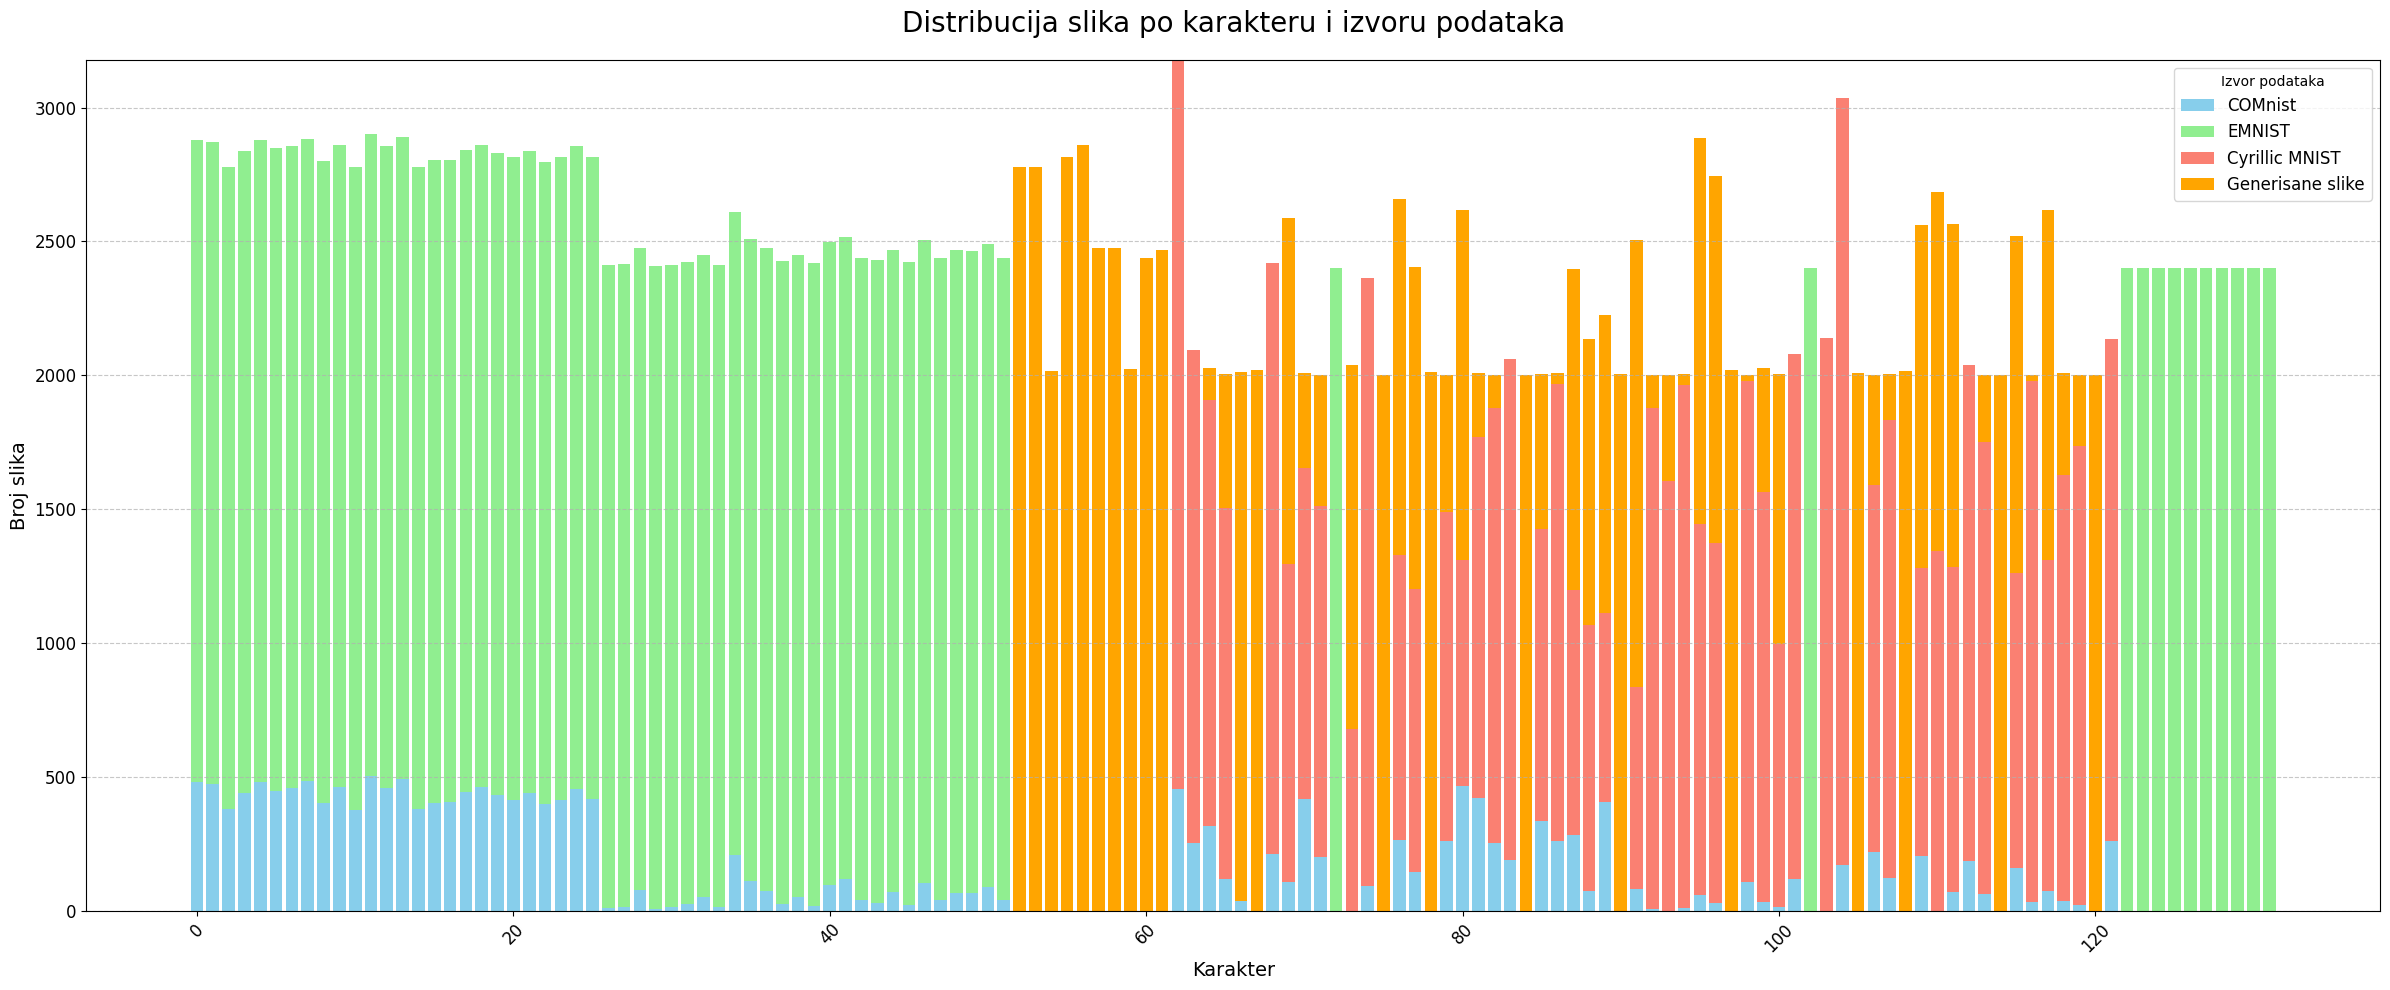

### Analiza porekla slika (iz `letters_per_dataset.csv` fajla)


In [8]:
# Celija koja pravi statostiku o datasetu na osnovu letters_per_dataset.csv fajla!
# Bice prikazan broj slika za svaki od skupa podataka
# Bice prikazano koji karakter ima najvise slika
# Bice prikazan grafik sa ucestaloscu svakog karaktera i predstavom odakle dolaze slike

csv_file_path = 'letters_per_dataset.csv'

if not os.path.exists(csv_file_path):
    print(f"Greška: Datoteka '{csv_file_path}' nije pronađena. Uverite se da se nalazi u ispravnom direktorijumu.")
else:
    # Učitavanje CSV datoteke
    df = pd.read_csv(csv_file_path)

    # Imenovanje kolona radi lakšeg rada
    df.columns = ['total_counts', 'comnist_counts', 'emnist_counts', 'cyrillicmnist_counts', 'generated_letters_count']

    # --- Prikaz tabele ---
    print("### Prikaz prvih 5 redova tabele sa raspodelom slika")
    print(df.head())
    print("\n")

    # --- Ukupna statistika ---
    total_comnist_images = df['comnist_counts'].sum()
    total_emnist_images = df['emnist_counts'].sum()
    total_cyrillic_images = df['cyrillicmnist_counts'].sum()
    total_generated_images = df['generated_letters_count'].sum()
    total_all_images = df['total_counts'].sum()

    print("### Ukupna statistika")
    print(f"Ukupan broj slika iz COMnist skupa: {total_comnist_images}")
    print(f"Ukupan broj slika iz EMNIST skupa: {total_emnist_images}")
    print(f"Ukupan broj slika iz Cyrillic MNIST skupa: {total_cyrillic_images}")
    print(f"Ukupan broj programski generisanih slika: {total_generated_images}")
    print(f"Ukupan broj slika u celom skupu podataka: {total_all_images}")
    print("\n")

    # --- Detalji o raspodeli ---
    print("### Detalji o raspodeli")
    print(f"Prosečan broj slika iz COMnist po karakteru: {df['comnist_counts'].mean():.2f}")
    print(f"Prosečan broj slika iz EMNIST po karakteru: {df['emnist_counts'].mean():.2f}")
    print(f"Prosečan broj slika iz Cyrillic MNIST po karakteru: {df['cyrillicmnist_counts'].mean():.2f}")
    
    # Prilagođavanje za 'total_counts'
    max_char = df.loc[df['total_counts'].idxmax()]
    
    print(f"Karakter sa najviše slika (ukupno): '{max_char.name}' ({max_char['total_counts']} slika)")
    print("\n")

    # --- Vizualizacija raspodele slika ---
    print("### Grafički prikaz raspodele slika po izvoru")

    # Kreiranje kolone 'Character' od indeksa, ako ne postoji (jer je to sad prvi stub)
    df['Character'] = df.index 

    # Kreiranje slozenog (stacked) grafikona
    fig, ax = plt.subplots(figsize=(24, 10))

    comnist_counts = df['comnist_counts']
    emnist_counts = df['emnist_counts']
    cyrillic_counts = df['cyrillicmnist_counts']
    generated_counts = df['generated_letters_count']
    
    # Crtanje stubića. 'bottom' parametar postavlja početak novog stuba
    p1 = ax.bar(df['Character'], comnist_counts, color='skyblue', label='COMnist')
    p2 = ax.bar(df['Character'], emnist_counts, bottom=comnist_counts, color='lightgreen', label='EMNIST')
    p3 = ax.bar(df['Character'], cyrillic_counts, bottom=comnist_counts + emnist_counts, color='salmon', label='Cyrillic MNIST')
    p4 = ax.bar(df['Character'], generated_counts, bottom=comnist_counts + emnist_counts + cyrillic_counts, color='orange', label='Generisane slike')

    ax.set_title('Distribucija slika po karakteru i izvoru podataka', fontsize=20, pad=20)
    ax.set_xlabel('Karakter', fontsize=14)
    ax.set_ylabel('Broj slika', fontsize=14)
    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='Izvor podataka', fontsize=12)

    plt.tight_layout()
    plt.show()

    # --- Dodatna analiza porekla slika ---
    print("### Analiza porekla slika (iz `letters_per_dataset.csv` fajla)")

# Izdvajanje teksta sa slike i formatiranje izlaza

In [8]:
# Kod koji sa slike izvlači tekst koristeći prosleđen model NM

def extract_text(image, model_nn, alphabet_labels):
    # Ovde ce biti rezultat
    test_result = ''
    # Ucitamo sliku
    test_color = image.copy()
    test_bin = image_bin(image_gray(test_color))

    # Oznacavamo ROI i prikazujemo sliku
    selected_roi_image, sorted_regions, regions_centers, sorted_rectangles = select_roi_test(test_color.copy(), invert_bin(test_bin))
    display_image(selected_roi_image)

    # Trazimo prosecne visine karaktera
    average_roi_height = 2.2 * np.mean(np.array([h for x, y, w, h in sorted_rectangles]))

    # Pravimo temp jer cemo iz njega u algoritmu brisati elemente 
    sorted_regions_temp = sorted_regions.copy()

    i = 0

    while len(regions_centers) > 0:
        # 1. Uzeti minimalnu y-vrednost centra karaktera u samom nizu centara i izdvojiti ga u poseban niz i obrisati iz trenutnog
        minv = min(regions_centers, key=lambda x: x[1])
        # Nabavljamo indeks minimalnog kako bismo znali sa kog indeksa brisemo u drugim nizovima
        minv_ind = regions_centers.index(minv)

        simillar_center = [regions_centers[minv_ind]]
        sorted_regions_row = [sorted_regions_temp[minv_ind]]
        sorted_rectangles_row = [sorted_rectangles[minv_ind]]

        # Brisanje elementa iz nizova
        regions_centers.remove(minv)
        del sorted_regions_temp[minv_ind]
        del sorted_rectangles[minv_ind]

        # 2. Proci kroz ostatak niza i proveriti da li postoje karakteri sa slicnom y-vrednost centra (y-centar +- (prosecna-visina-svih-karaktera / 2)) 
        # i dodati ih u posebne nizove i obrisati iz trenutnih nizova
        simillar_center += [el for el in regions_centers if el[1] >= minv[1] - int(average_roi_height) and el[1] <= minv[1] + int(average_roi_height)]

        for x in simillar_center:
            if x in regions_centers:
                ind = regions_centers.index(x)
                regions_centers.remove(x)
                sorted_regions_row += [sorted_regions_temp[ind]]
                sorted_rectangles_row += [sorted_rectangles[ind]]
                del sorted_regions_temp[ind]
                del sorted_rectangles[ind]

        # Korisceno da vidim da li sve radi kako sam zeleo :)
        #print(len(regions_centers), len(sorted_regions_temp), len(sorted_rectangles))
        #print(len(simillar_center), len(sorted_regions_row), len(sorted_rectangles_row))

        # 3. Sortirati poseban niz po x-vrednosti centara i sracunati udaljenosti izmedju svaka 2 karaktera kako bismo mogli uraditi KMeans nad ovim redom
        # Spajamo regione i centre u jedan niz
        sorted_regions_and_centers_and_rectangles = []
        for i in range(len(sorted_regions_row)):
            sorted_regions_and_centers_and_rectangles += [[sorted_regions_row[i], simillar_center[i], sorted_rectangles_row[i]]]

        # Sortiramo niz po x vrednosti i izvlacimo regione i centre u poseban niz
        # Ovaj korak je bio potreban jer nisam bio siguran u to da li ce elementi ocuvati sortiranost iz prethodnih koraka
        sorted_regions_and_centers_and_rectangles = sorted(sorted_regions_and_centers_and_rectangles, key=lambda x: x[1][0])
        sorted_regions_row = [region[0] for region in sorted_regions_and_centers_and_rectangles]
        sorted_centers_row = [region[1] for region in sorted_regions_and_centers_and_rectangles]
        sorted_rectangles_row = [region[2] for region in sorted_regions_and_centers_and_rectangles]

        sorted_regions_row = [invert_bin(region) for region in sorted_regions_row]

        # Racunamo distance i primenjujemo KMeans
        if len(sorted_regions_row) > 2:
            region_distances = []
            for index in range(0, len(sorted_rectangles_row) - 1):
                current = sorted_rectangles_row[index]
                next_rect = sorted_rectangles_row[index + 1]
                distance = next_rect[0] - (current[0] + current[2]) # x_next - (x_current + w_current)
                region_distances.append(distance)
    
            region_distances = np.array(region_distances).reshape(len(region_distances), 1)
            k_means = KMeans(n_clusters=2, n_init=10)
            k_means.fit(region_distances)

            # 4. Prikazemo rezultat samo tog jednog reda sa razmacima i dodamo '\n' na kraj rezultata
            test_inputs = prepare_for_cnn(sorted_regions_row)
            result = model_nn.predict(test_inputs)

            test_result += display_result_with_spaces(result, alphabet_labels, k_means)
            test_result += '\n'
        else:
            # 4. Prikazemo rezultat samo tog jednog reda sa razmacima i dodamo '\n' na kraj rezultata
            test_inputs = prepare_for_cnn(sorted_regions_row)
            result = model_nn.predict(test_inputs)

            test_result += display_result_with_spaces(result, alphabet_labels, None)
            test_result += '\n'

        # 5. Ponavljamo korake 1-4 sve dok ne dobijemo prazan red centara

    return test_result

In [9]:
def decimal_to_alphabet(decimal_str, alphabet, alphabet_labels):
    result = ""
    i = 0
    while i < len(decimal_str):
        char = decimal_str[i]

        if char in ['\n', ' ']:
            result += char
            i += 1
        else:
            if i + 2 < len(decimal_str):
                decimal_code = decimal_str[i:i+3]
                
                if decimal_code in alphabet_labels:
                    result += alphabet[int(decimal_code, 10)]
                    i += 3
                else:
                    result += char
                    i += 1
                
            else:
                result += char
                i += 1
    
    return result

# Kreiranje i treniranje NM za sva slova

In [10]:
# Kreiranje alfabeta neuronske mreže

# Ideja je da folderi se nazivaju po indeksima karaktera koji su u nizu
# Primer: Velika slova B se nalaze u folderu 001, što je indeks tog karaktera u alfabetu
# Kako se budu dodavali karakteri ići će ovako redom:
# 1. Velika slova engleske latinice
# 2. Mala slova engleske latinice
# 3. Velika slova Č, Ć, Đ, Ž i Š 
# 4. Mala slova č, ć, đ, ž i š
# 5. Velika slova ćirilice
# 6. Mala slova ćirilice
# 7. Cifre

alphabet = [ 
            # Velika slova engleske latinice
            'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
            'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
            
            # Mala slova enegleske latinice
            'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
            'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z',
            
            # Velika, pa zatim mala slova Č, Ć, Đ, Ž i Š
            'Č', 'Ć', 'Đ', 'Ž', 'Š', 
            'č', 'ć', 'đ', 'ž', 'š',

            # Velika slova ćirilice 
            'А', 'Б', 'В', 'Г', 'Д', 'Ђ', 'Е', 'Ж', 'З', 'И', 
            'Ј', 'К', 'Л', 'Љ', 'М', 'Н', 'Њ', 'О', 'П', 'Р', 
            'С', 'Т', 'Ћ', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Џ', 'Ш',

            # Mala slova ćirilice 
            'а', 'б', 'в', 'г', 'д', 'ђ', 'е', 'ж', 'з', 'и', 
            'ј', 'к', 'л', 'љ', 'м', 'н', 'њ', 'о', 'п','р', 
            'с', 'т', 'ћ', 'у', 'ф', 'х', 'ц', 'ч', 'џ', 'ш',

            # Cifre
            '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'
            ]

# Labele se cuvaju u formatu ['001', '002', ...]
alphabet_labels = os.listdir("../data/train_small/")

Found 105600 files belonging to 132 classes.
Found 26400 files belonging to 132 classes.

Training started...
Epoch 1/100
3300/3300 [==============================] - 716s 216ms/step - loss: 2.1510 - accuracy: 0.4068 - val_loss: 0.9166 - val_accuracy: 0.6518 - lr: 0.0010
Epoch 2/100
3300/3300 [==============================] - 717s 217ms/step - loss: 1.1461 - accuracy: 0.6032 - val_loss: 0.7735 - val_accuracy: 0.6864 - lr: 0.0010
Epoch 3/100
3300/3300 [==============================] - 713s 216ms/step - loss: 0.9740 - accuracy: 0.6438 - val_loss: 0.7099 - val_accuracy: 0.7006 - lr: 0.0010
Epoch 4/100
3300/3300 [==============================] - 710s 215ms/step - loss: 0.8882 - accuracy: 0.6667 - val_loss: 0.7103 - val_accuracy: 0.7036 - lr: 0.0010
Epoch 5/100
3300/3300 [==============================] - 731s 222ms/step - loss: 0.8288 - accuracy: 0.6810 - val_loss: 1.3779 - val_accuracy: 0.5507 - lr: 0.0010
Epoch 6/100
3300/3300 [==============================] - 737s 223ms/step - loss:

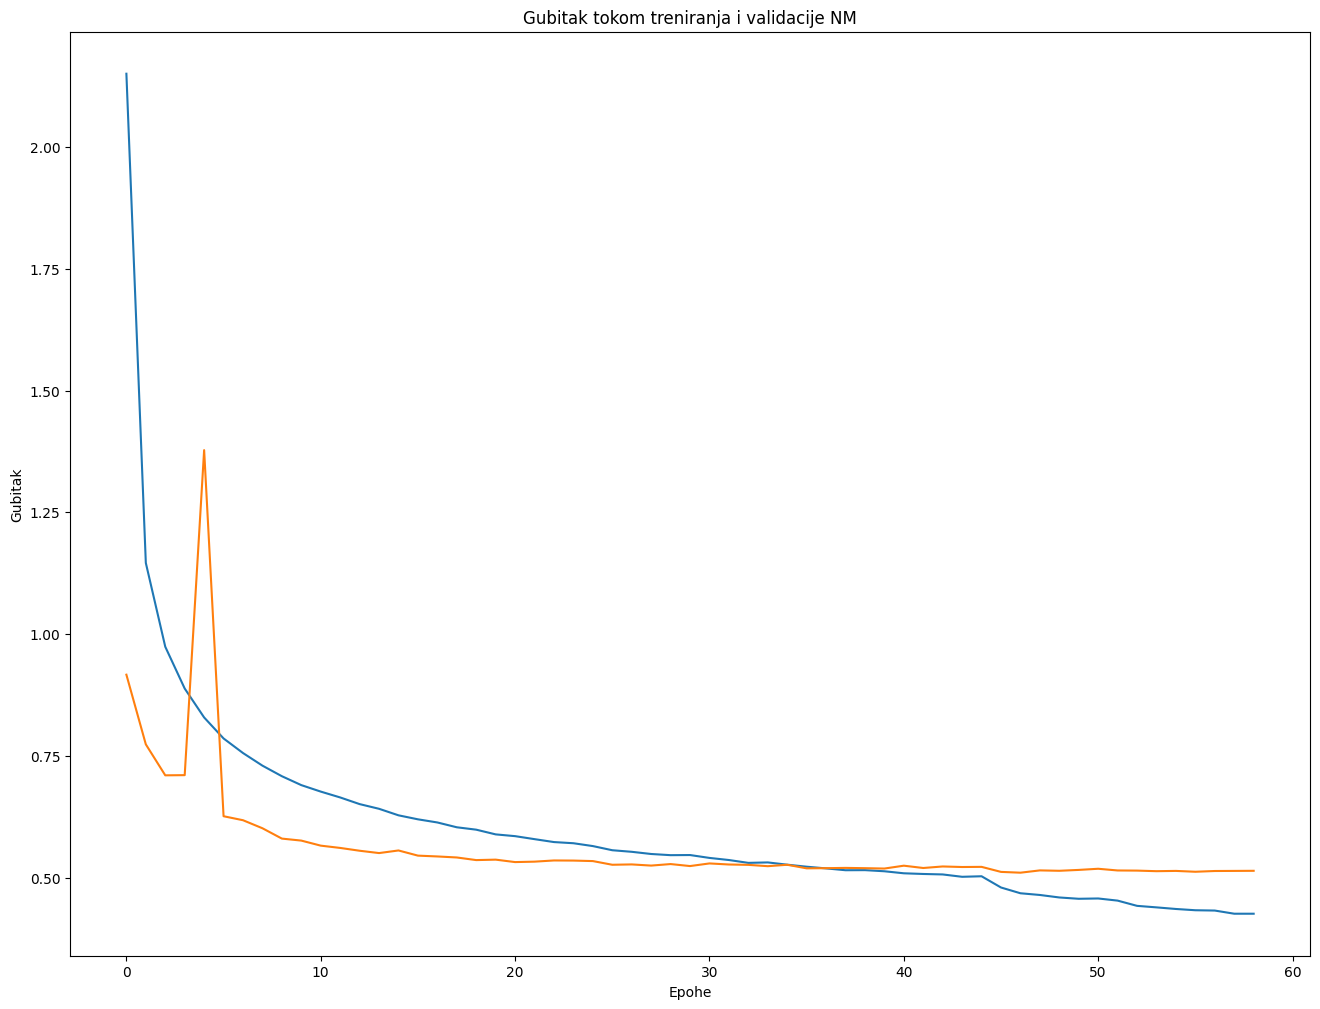

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 62, 62, 32)        320       
                                                                 
 batch_normalization_6 (Bat  (None, 62, 62, 32)        128       
 chNormalization)                                                
                                                                 
 conv2d_5 (Conv2D)           (None, 60, 60, 32)        9248      
                                                                 
 batch_normalization_7 (Bat  (None, 60, 60, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 30, 30, 32)        0         
 g2D)                                                            
                                                      

In [18]:
train_dataset = image_dataset_from_directory(
    '../data/train_small/',
    batch_size=32,
    color_mode='grayscale',
    image_size=(64,64),
    label_mode='categorical'
)

validation_dataset = image_dataset_from_directory(
    '../data/val_small/',
    batch_size=32,
    color_mode='grayscale',
    image_size=(64,64),
    label_mode='categorical'
)

model = create_cnn(output_size=(len(alphabet_labels)))
model = train_cnn(model, train_dataset, validation_dataset, epochs=100)
model.summary()

# Kreiranje i treniranje NM za ćirilična slova

In [13]:
# Kreiranje alfabeta neuronske mreže

# Ideja je da folderi se nazivaju po indeksima karaktera koji su u nizu
# Primer: Velika slova B se nalaze u folderu 001, što je indeks tog karaktera u alfabetu
# Kako se budu dodavali karakteri ići će ovako redom:
# 1. Velika slova ćirilice
# 2. Mala slova ćirilice
# 3. Cifre

alphabet_cyrillic = [ 
            # Velika slova ćirilice 
            'А', 'Б', 'В', 'Г', 'Д', 'Ђ', 'Е', 'Ж', 'З', 'И', 
            'Ј', 'К', 'Л', 'Љ', 'М', 'Н', 'Њ', 'О', 'П', 'Р', 
            'С', 'Т', 'Ћ', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Џ', 'Ш',

            # Mala slova ćirilice 
            'а', 'б', 'в', 'г', 'д', 'ђ', 'е', 'ж', 'з', 'и', 
            'ј', 'к', 'л', 'љ', 'м', 'н', 'њ', 'о', 'п','р', 
            'с', 'т', 'ћ', 'у', 'ф', 'х', 'ц', 'ч', 'џ', 'ш',

            # Cifre
            '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'
            ]

# Labele se cuvaju u formatu ['001', '002', ...]
alphabet_cyrillic_labels = os.listdir("../data/train_small_cyrillic/")

Found 28000 files belonging to 70 classes.
Found 7000 files belonging to 70 classes.

Training started...
Epoch 1/56
875/875 [==============================] - 217s 244ms/step - loss: 2.5839 - accuracy: 0.3411 - val_loss: 0.8119 - val_accuracy: 0.7319 - lr: 0.0010
Epoch 2/56
875/875 [==============================] - 195s 223ms/step - loss: 1.0903 - accuracy: 0.6531 - val_loss: 0.5650 - val_accuracy: 0.7946 - lr: 0.0010
Epoch 3/56
875/875 [==============================] - 198s 226ms/step - loss: 0.7992 - accuracy: 0.7331 - val_loss: 0.4368 - val_accuracy: 0.8371 - lr: 0.0010
Epoch 4/56
875/875 [==============================] - 191s 218ms/step - loss: 0.6709 - accuracy: 0.7782 - val_loss: 0.3927 - val_accuracy: 0.8594 - lr: 0.0010
Epoch 5/56
875/875 [==============================] - 197s 225ms/step - loss: 0.5892 - accuracy: 0.7977 - val_loss: 0.3849 - val_accuracy: 0.8554 - lr: 0.0010
Epoch 6/56
875/875 [==============================] - 198s 226ms/step - loss: 0.5536 - accuracy: 0.

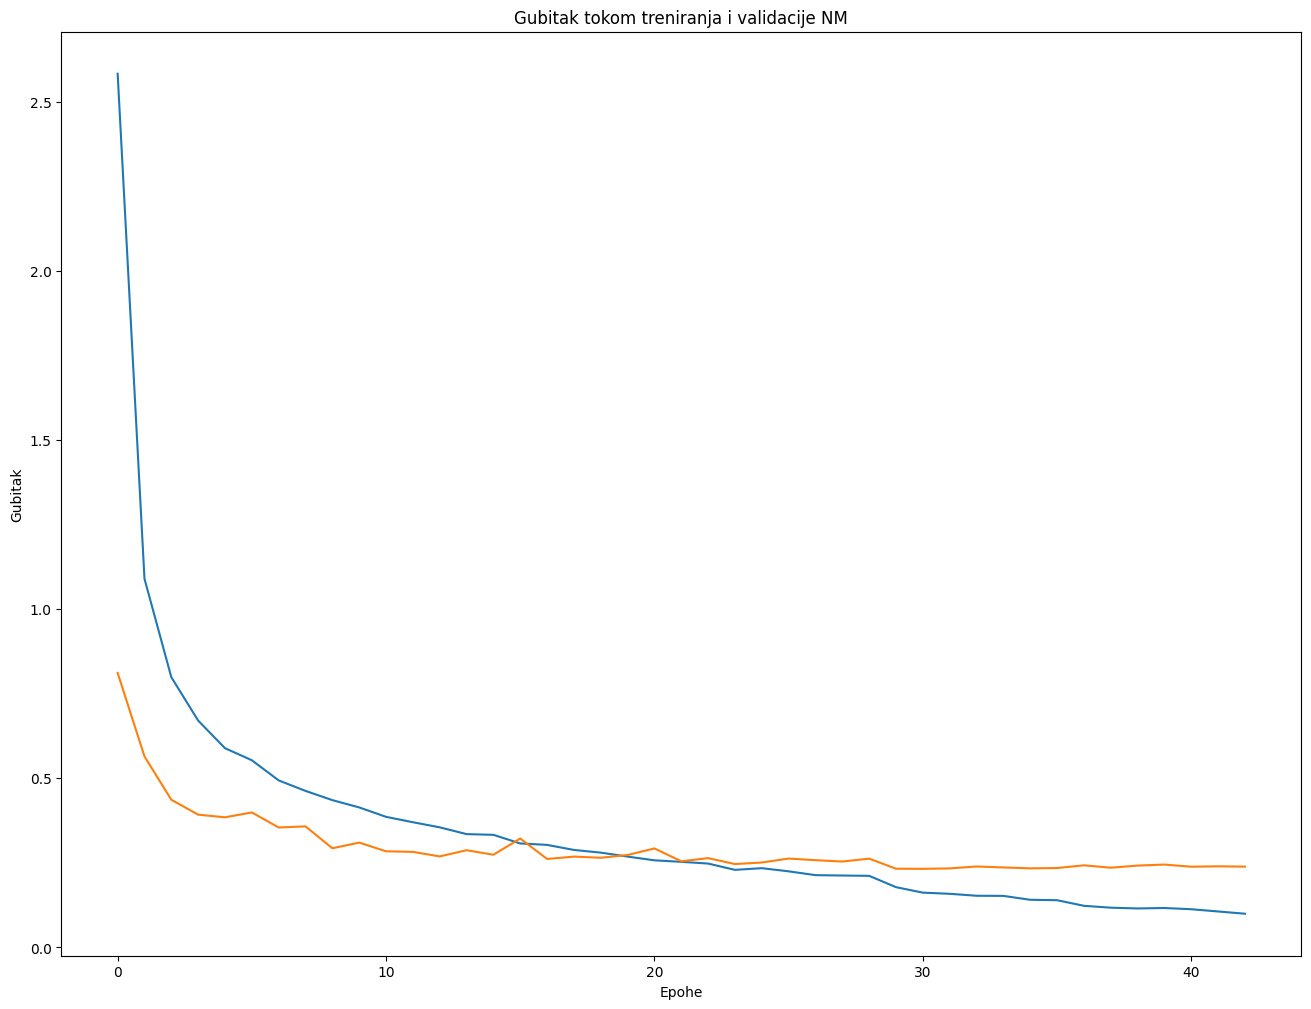

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_35 (Conv2D)          (None, 62, 62, 32)        320       
                                                                 
 batch_normalization_45 (Ba  (None, 62, 62, 32)        128       
 tchNormalization)                                               
                                                                 
 conv2d_36 (Conv2D)          (None, 60, 60, 32)        9248      
                                                                 
 batch_normalization_46 (Ba  (None, 60, 60, 32)        128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_20 (MaxPooli  (None, 30, 30, 32)        0         
 ng2D)                                                           
                                                      

In [75]:
train_dataset_cyrillic = image_dataset_from_directory(
    '../data/train_small_cyrillic/',
    batch_size=32,
    color_mode='grayscale',
    image_size=(64,64),
    label_mode='categorical'
)

validation_dataset_cyrillic = image_dataset_from_directory(
    '../data/val_small_cyrillic/',
    batch_size=32,
    color_mode='grayscale',
    image_size=(64,64),
    label_mode='categorical'
)

model_cyrillic = create_cnn(output_size=(len(alphabet_cyrillic_labels)))
model_cyrillic = train_cnn(model_cyrillic, train_dataset_cyrillic, validation_dataset_cyrillic, epochs=56)
model_cyrillic.summary()

# Kreiranje i treniranje NM za latinična slova

In [14]:
# Kreiranje alfabeta neuronske mreže

# Ideja je da folderi se nazivaju po indeksima karaktera koji su u nizu
# Primer: Velika slova B se nalaze u folderu 001, što je indeks tog karaktera u alfabetu
# Kako se budu dodavali karakteri ići će ovako redom:
# 1. Velika slova engleske latinice
# 2. Mala slova engleske latinice
# 3. Velika slova Č, Ć, Đ, Ž i Š 
# 4. Mala slova č, ć, đ, ž i š
# 5. Cifre

alphabet_latin = [ 
            # Velika slova engleske latinice
            'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
            'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
            
            # Mala slova enegleske latinice
            'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
            'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z',
            
            # Velika, pa zatim mala slova Č, Ć, Đ, Ž i Š
            'Č', 'Ć', 'Đ', 'Ž', 'Š', 
            'č', 'ć', 'đ', 'ž', 'š',

            # Cifre
            '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'
            ]

# Labele se cuvaju u formatu ['001', '002', ...]
alphabet_latin_labels = os.listdir("../data/train_small_latin/")

Found 28800 files belonging to 72 classes.
Found 7200 files belonging to 72 classes.

Training started...
Epoch 1/56
900/900 [==============================] - 230s 248ms/step - loss: 2.9271 - accuracy: 0.2480 - val_loss: 1.3690 - val_accuracy: 0.5218 - lr: 0.0010
Epoch 2/56
900/900 [==============================] - 205s 228ms/step - loss: 1.5215 - accuracy: 0.4797 - val_loss: 1.0126 - val_accuracy: 0.5817 - lr: 0.0010
Epoch 3/56
900/900 [==============================] - 208s 231ms/step - loss: 1.2514 - accuracy: 0.5330 - val_loss: 0.9035 - val_accuracy: 0.6007 - lr: 0.0010
Epoch 4/56
900/900 [==============================] - 203s 226ms/step - loss: 1.1289 - accuracy: 0.5619 - val_loss: 0.8534 - val_accuracy: 0.6158 - lr: 0.0010
Epoch 5/56
900/900 [==============================] - 203s 226ms/step - loss: 1.0647 - accuracy: 0.5723 - val_loss: 0.8562 - val_accuracy: 0.6200 - lr: 0.0010
Epoch 6/56
900/900 [==============================] - 204s 226ms/step - loss: 1.0176 - accuracy: 0.

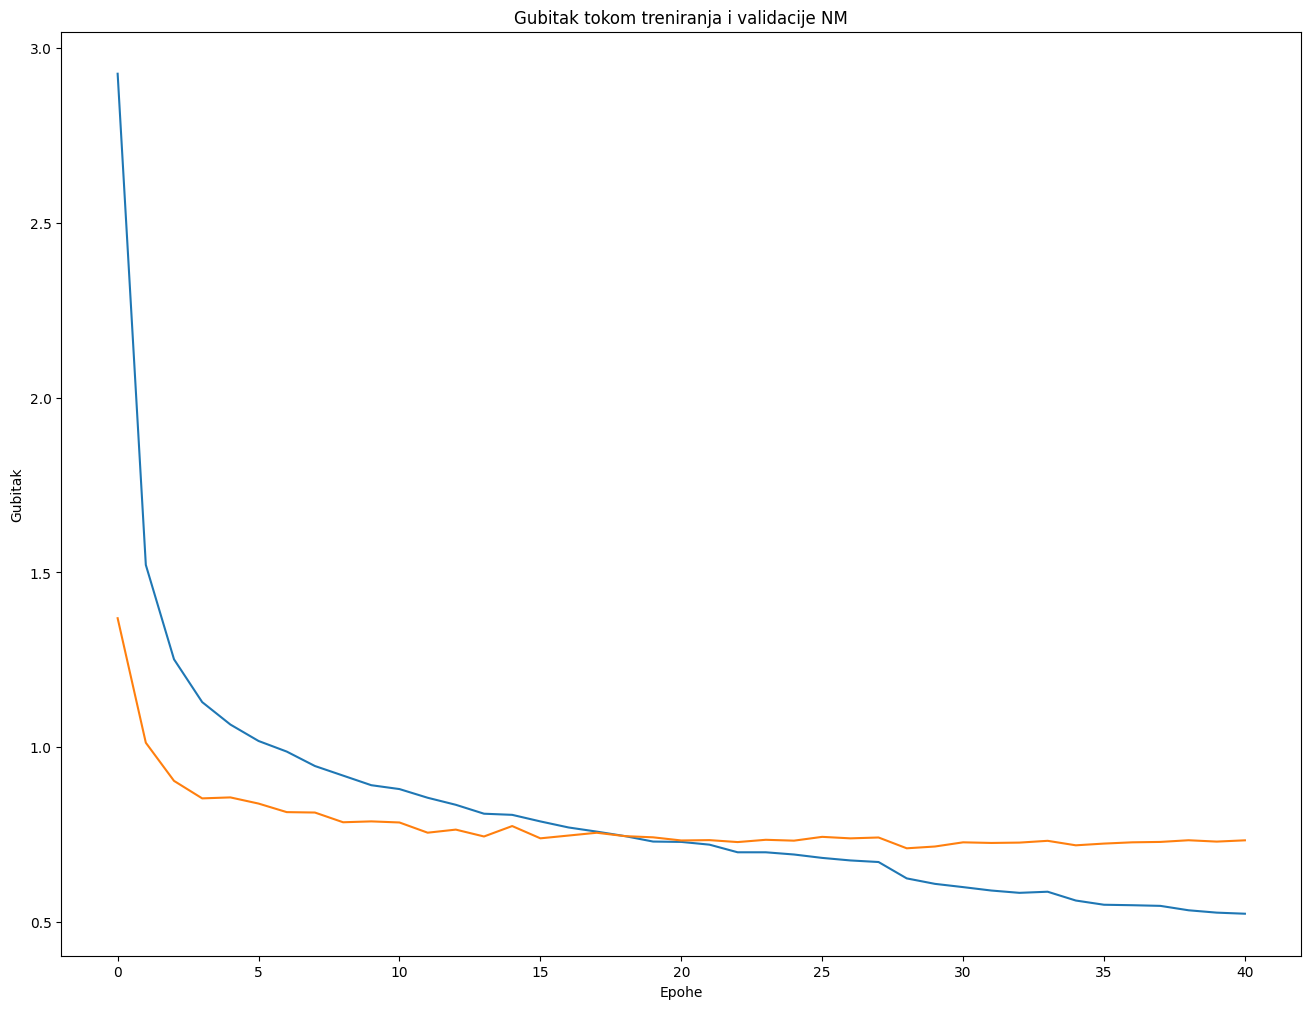

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_42 (Conv2D)          (None, 62, 62, 32)        320       
                                                                 
 batch_normalization_54 (Ba  (None, 62, 62, 32)        128       
 tchNormalization)                                               
                                                                 
 conv2d_43 (Conv2D)          (None, 60, 60, 32)        9248      
                                                                 
 batch_normalization_55 (Ba  (None, 60, 60, 32)        128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_24 (MaxPooli  (None, 30, 30, 32)        0         
 ng2D)                                                           
                                                      

In [78]:
train_dataset_latin = image_dataset_from_directory(
    '../data/train_small_latin/',
    batch_size=32,
    color_mode='grayscale',
    image_size=(64,64),
    label_mode='categorical'
)

validation_dataset_latin = image_dataset_from_directory(
    '../data/val_small_latin/',
    batch_size=32,
    color_mode='grayscale',
    image_size=(64,64),
    label_mode='categorical'
)

model_latin = create_cnn(output_size=(len(alphabet_latin_labels)))
model_latin = train_cnn(model_latin, train_dataset_latin, validation_dataset_latin, epochs=56)
model_latin.summary()

# Čuvanje i učitavanje modela NM

In [3]:
# Cuvanje modela
model.save('ocr_model.h5')
model_cyrillic.save('ocr_model_cyrillic.h5')
model_latin.save('ocr_model_latin.h5')

d:\Projects\MITNOP-Handwriting-OCR\.venv\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [15]:
# Ovde je moguce ucitati model iz h5 fajla
model_path = './ocr_model.h5' # Fajl dobijen upotrebom model.save()

try:
    model = tf.keras.models.load_model(model_path)
    print(f"Model successfully loaded from: {model_path}")
    model.summary()
except Exception as e:
    print(f"Error loading model: {e}")

model_path_cyrillic = './ocr_model_cyrillic.h5' # Fajl dobijen upotrebom model.save()
try:
    model_cyrillic = tf.keras.models.load_model(model_path_cyrillic)
    print(f"Model successfully loaded from: {model_path_cyrillic}")
    model_cyrillic.summary()
except Exception as e:
    print(f"Error loading model: {e}")

model_path_latin = './ocr_model_latin.h5' # Fajl dobijen upotrebom model.save()
try:
    model_latin = tf.keras.models.load_model(model_path_latin)
    print(f"Model successfully loaded from: {model_path_latin}")
    model_latin.summary()
except Exception as e:
    print(f"Error loading model: {e}")

Model successfully loaded from: ./ocr_model.h5
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 62, 62, 32)        320       
                                                                 
 batch_normalization_6 (Bat  (None, 62, 62, 32)        128       
 chNormalization)                                                
                                                                 
 conv2d_5 (Conv2D)           (None, 60, 60, 32)        9248      
                                                                 
 batch_normalization_7 (Bat  (None, 60, 60, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 30, 30, 32)        0         
 g2D)                                                            
       

# Matrica konfuzije NM za sva slova

In [83]:
def confusion_matrix_creation(real_labels, predicted_results, save_path=None):
    cm = confusion_matrix(real_labels, predicted_results)
    n_classes = cm.shape[0]
    
    # Adaptive sizing
    fig_size = min(20, max(8, n_classes * 0.3))
    font_size = max(2, 100 // n_classes)
    
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    
    # Create the heatmap using matplotlib's imshow
    im = ax.imshow(cm, interpolation='nearest', cmap='Purples')
    
    # Add colorbar
    plt.colorbar(im, shrink=0.8)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(n_classes):
        for j in range(n_classes):
            # Only show text if matrix is not too large or value is significant
            if n_classes <= 50 or cm[i, j] > cm.max() * 0.05:
                color = "white" if cm[i, j] > thresh else "black"
                ax.text(j, i, str(cm[i, j]), ha="center", va="center", 
                       color=color, fontsize=font_size)
    
    # Set labels and ticks
    ax.set_xlabel("Procenjena klasa", fontsize=14)
    ax.set_ylabel("Stvarna klasa", fontsize=14)
    ax.set_title("Model - Matrica konfuzije", fontsize=16)
    
    # Set tick marks
    tick_marks = np.arange(n_classes)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    
    # Rotate labels if needed
    if n_classes > 15:
        plt.setp(ax.get_xticklabels(), rotation=90)
    elif n_classes > 8:
        plt.setp(ax.get_xticklabels(), rotation=45)
    
    # Adjust font size for tick labels
    ax.tick_params(axis='both', which='major', labelsize=max(6, font_size))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return cm


In [21]:
dir = "../data/val_small/"

real_results = []
predicted_results = []

for dir2 in os.listdir(dir):
    dirr = os.path.join(dir, dir2)
    for image_path in os.listdir(dirr):
        img = image_bin(image_gray(load_image(os.path.join(dirr,image_path))))
        prediction = model.predict(np.expand_dims(img, axis=0))

        predicted_results.append(winner(prediction[0]))
        real_results.append(dir2)
    print(f"Processed directory: {dir2}")

print("Real results:", real_results)
print("Predicted results:", predicted_results)

1/1 [==============================] - 0s 22ms/step
Processed directory: 000
1/1 [==============================] - 0s 22ms/step
Processed directory: 001
1/1 [==============================] - 0s 23ms/step
Processed directory: 002
1/1 [==============================] - 0s 23ms/step
Processed directory: 003
1/1 [==============================] - 0s 24ms/step
Processed directory: 004
1/1 [==============================] - 0s 24ms/step
Processed directory: 005
1/1 [==============================] - 0s 24ms/step
Processed directory: 006
1/1 [==============================] - 0s 23ms/step
Processed directory: 007
1/1 [==============================] - 0s 22ms/step
Processed directory: 008
1/1 [==============================] - 0s 24ms/step
Processed directory: 009
1/1 [==============================] - 0s 24ms/step
Processed directory: 010
1/1 [==============================] - 0s 24ms/step
Processed directory: 011
1/1 [==============================] - 0s 22ms/step
Processed directory: 012

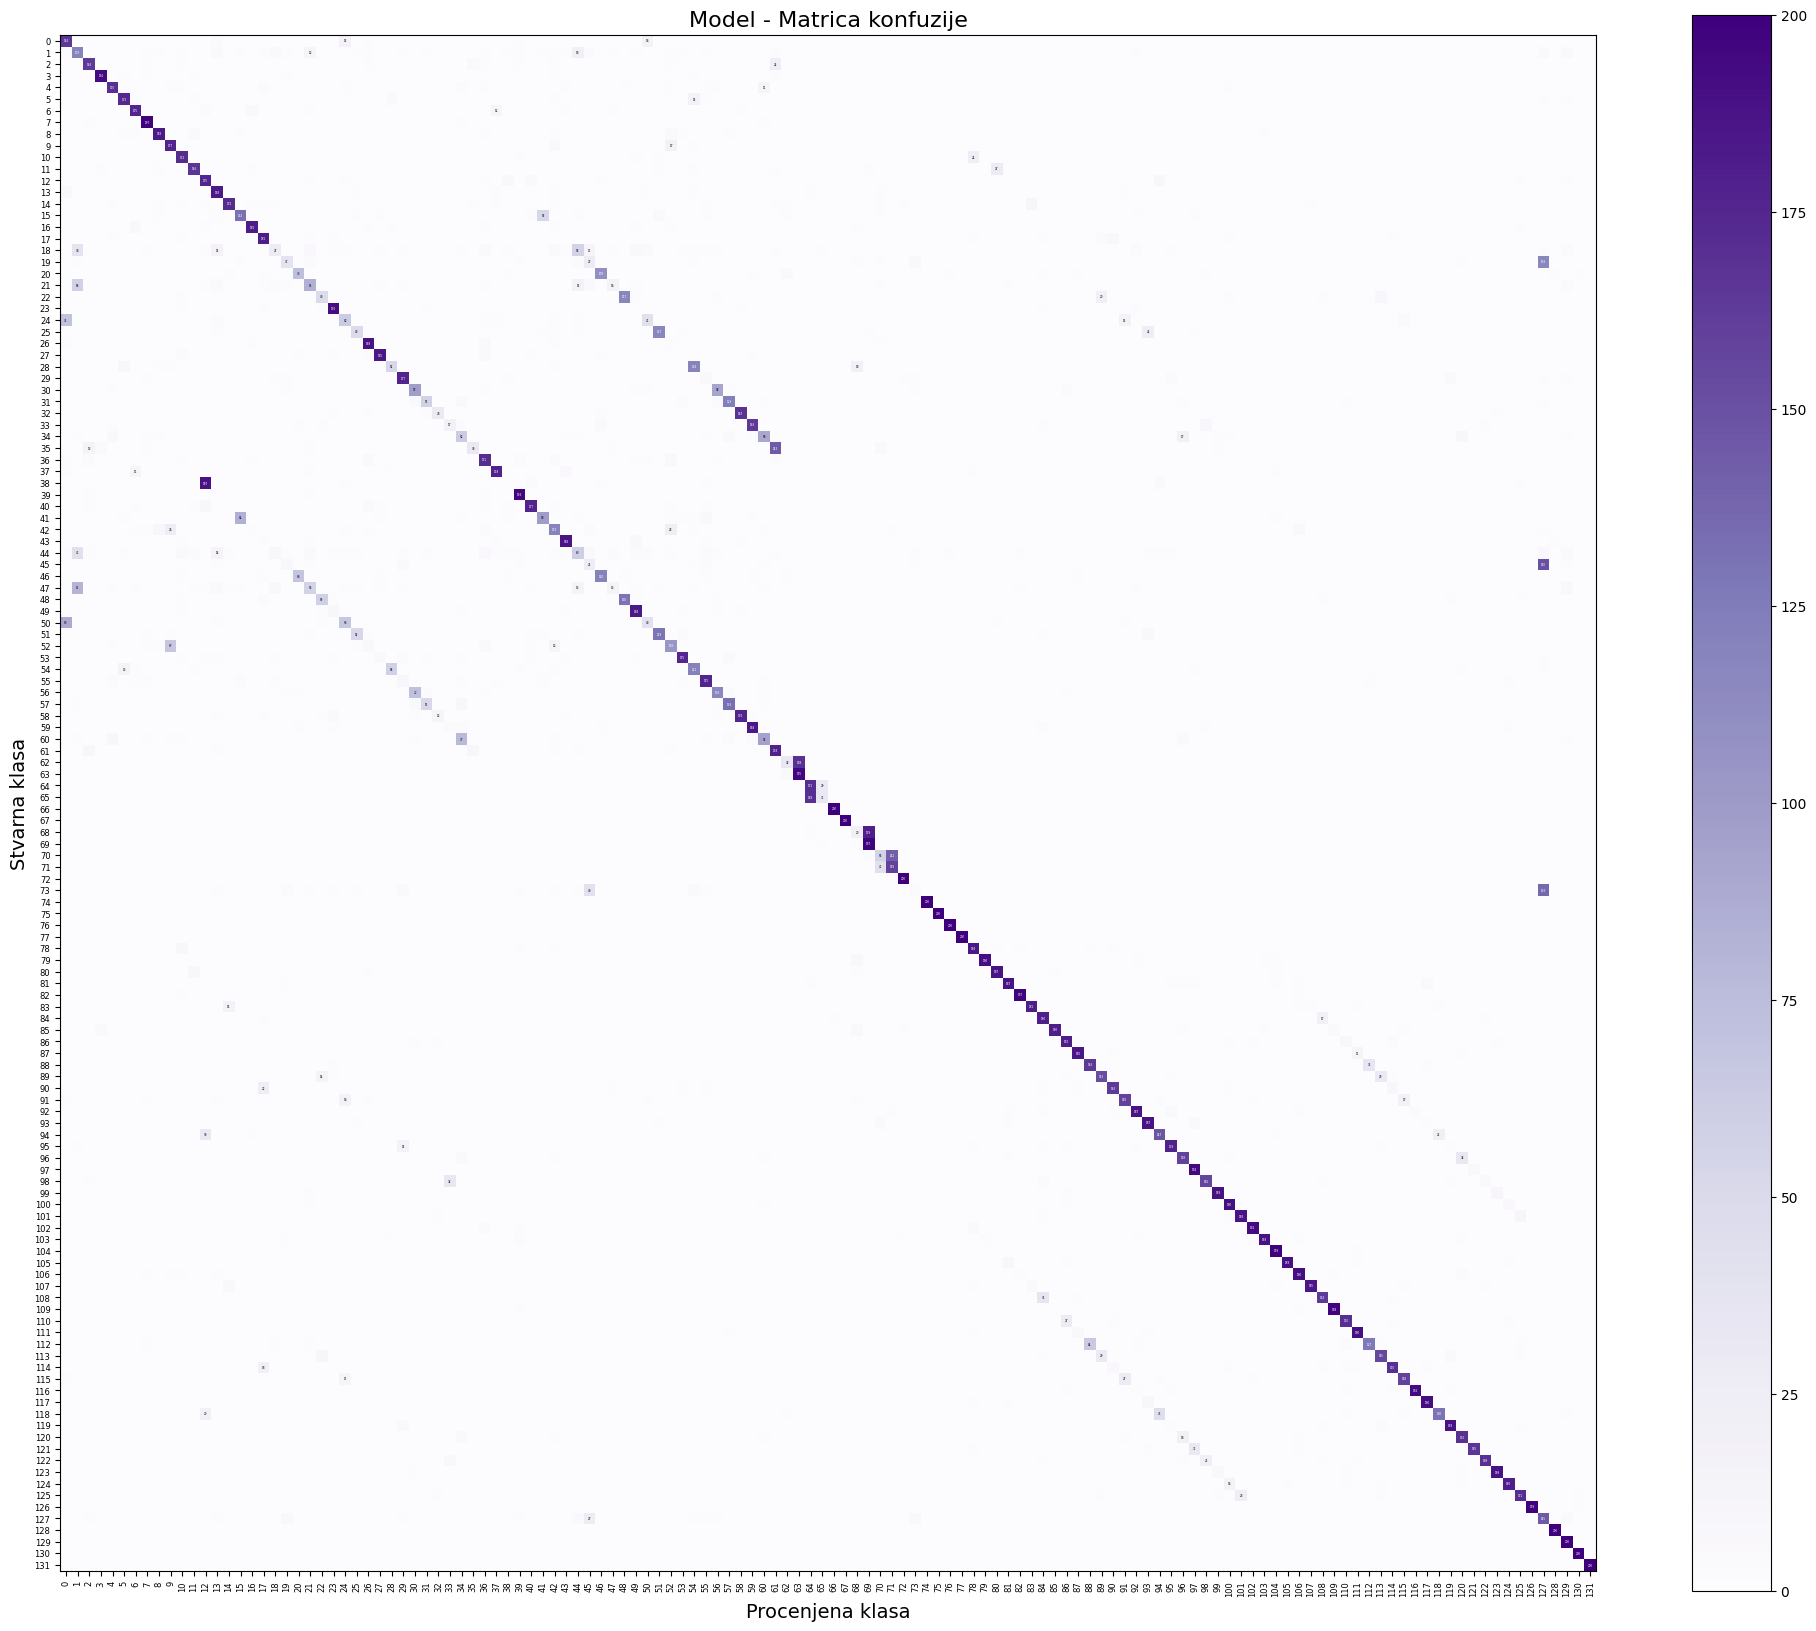

In [ ]:
predicted_results_labels = [decimal_to_alphabet(alphabet_labels[result], alphabet, alphabet_labels) for result in predicted_results]
real_labels = [decimal_to_alphabet(x, alphabet, alphabet_labels) for x in real_results]
cm = confusion_matrix_creation(real_labels, predicted_results_labels, 'confusion_matrix.png')

# Matrica konfuzije NM za ćirilična slova

In [88]:
dir = "../data/val_small_cyrillic/"

real_results_cyrillic = []
predicted_results_cyrillic = []

for dir2 in os.listdir(dir):
    dirr = os.path.join(dir, dir2)
    for image_path in os.listdir(dirr):
        img = image_bin(image_gray(load_image(os.path.join(dirr,image_path))))
        prediction = model_cyrillic.predict(np.expand_dims(img, axis=0))

        predicted_results_cyrillic.append(winner(prediction[0]))
        real_results_cyrillic.append(dir2)
    print(f"Processed directory: {dir2}")

print("Real results:", real_results_cyrillic)
print("Predicted results:", predicted_results_cyrillic)

1/1 [==============================] - 0s 26ms/step
Processed directory: 000
1/1 [==============================] - 0s 23ms/step
Processed directory: 001
1/1 [==============================] - 0s 24ms/step
Processed directory: 002
1/1 [==============================] - 0s 24ms/step
Processed directory: 003
1/1 [==============================] - 0s 37ms/step
Processed directory: 004
1/1 [==============================] - 0s 25ms/step
Processed directory: 005
1/1 [==============================] - 0s 25ms/step
Processed directory: 006
1/1 [==============================] - 0s 25ms/step
Processed directory: 007
1/1 [==============================] - 0s 26ms/step
Processed directory: 008
1/1 [==============================] - 0s 26ms/step
Processed directory: 009
1/1 [==============================] - 0s 26ms/step
Processed directory: 010
1/1 [==============================] - 0s 28ms/step
Processed directory: 011
1/1 [==============================] - 0s 30ms/step
Processed directory: 012

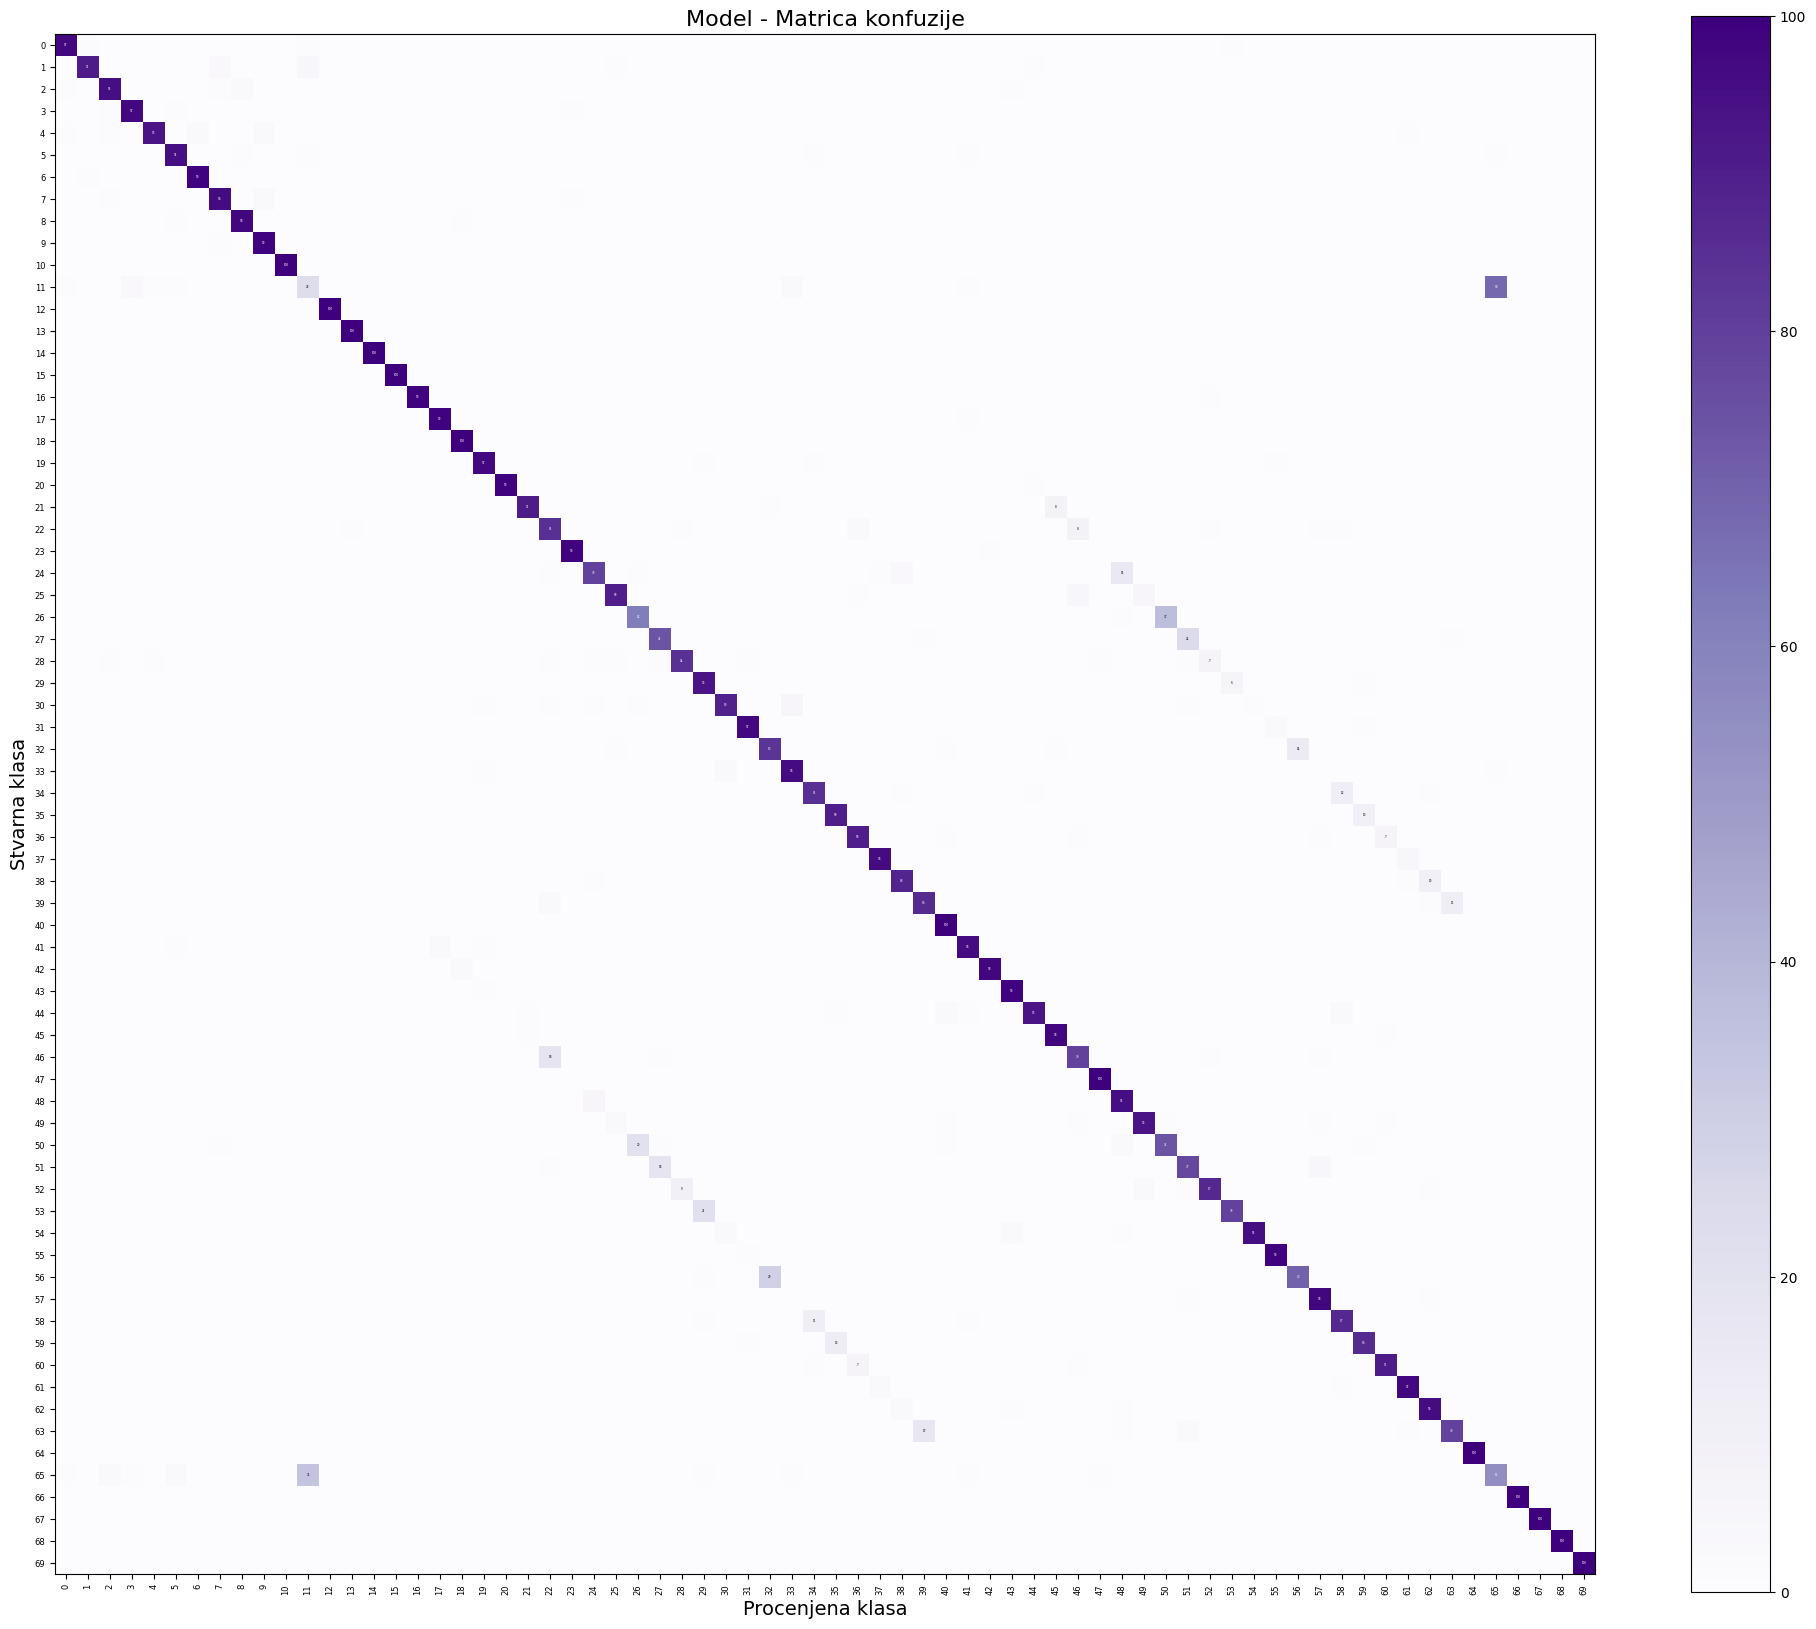

In [91]:
predicted_results_labels_cyrillic = [decimal_to_alphabet(alphabet_cyrillic_labels[result], alphabet_cyrillic, alphabet_cyrillic_labels) for result in predicted_results_cyrillic]
real_labels_cyrillic = [decimal_to_alphabet(x, alphabet_cyrillic, alphabet_cyrillic_labels) for x in real_results_cyrillic]
cm_cyrillic = confusion_matrix_creation(real_labels_cyrillic, predicted_results_labels_cyrillic, 'confusion_matrix_cyrillic.png')

# Matrica konfuzije NM za latinična slova

In [92]:
dir = "../data/val_small_latin/"

real_results_latin = []
predicted_results_latin = []

for dir2 in os.listdir(dir):
    dirr = os.path.join(dir, dir2)
    for image_path in os.listdir(dirr):
        img = image_bin(image_gray(load_image(os.path.join(dirr,image_path))))
        prediction = model_latin.predict(np.expand_dims(img, axis=0))

        predicted_results_latin.append(winner(prediction[0]))
        real_results_latin.append(dir2)
    print(f"Processed directory: {dir2}")

print("Real results:", real_results_latin)
print("Predicted results:", predicted_results_latin)

1/1 [==============================] - 0s 41ms/step
Processed directory: 000
1/1 [==============================] - 0s 41ms/step
Processed directory: 001
1/1 [==============================] - 0s 47ms/step
Processed directory: 002
1/1 [==============================] - 0s 48ms/step
Processed directory: 003
1/1 [==============================] - 0s 41ms/step
Processed directory: 004
1/1 [==============================] - 0s 30ms/step
Processed directory: 005
1/1 [==============================] - 0s 43ms/step
Processed directory: 006
1/1 [==============================] - 0s 45ms/step
Processed directory: 007
1/1 [==============================] - 0s 43ms/step
Processed directory: 008
1/1 [==============================] - 0s 58ms/step
Processed directory: 009
1/1 [==============================] - 0s 48ms/step
Processed directory: 010
1/1 [==============================] - 0s 49ms/step
Processed directory: 011
1/1 [==============================] - 0s 63ms/step
Processed directory: 012

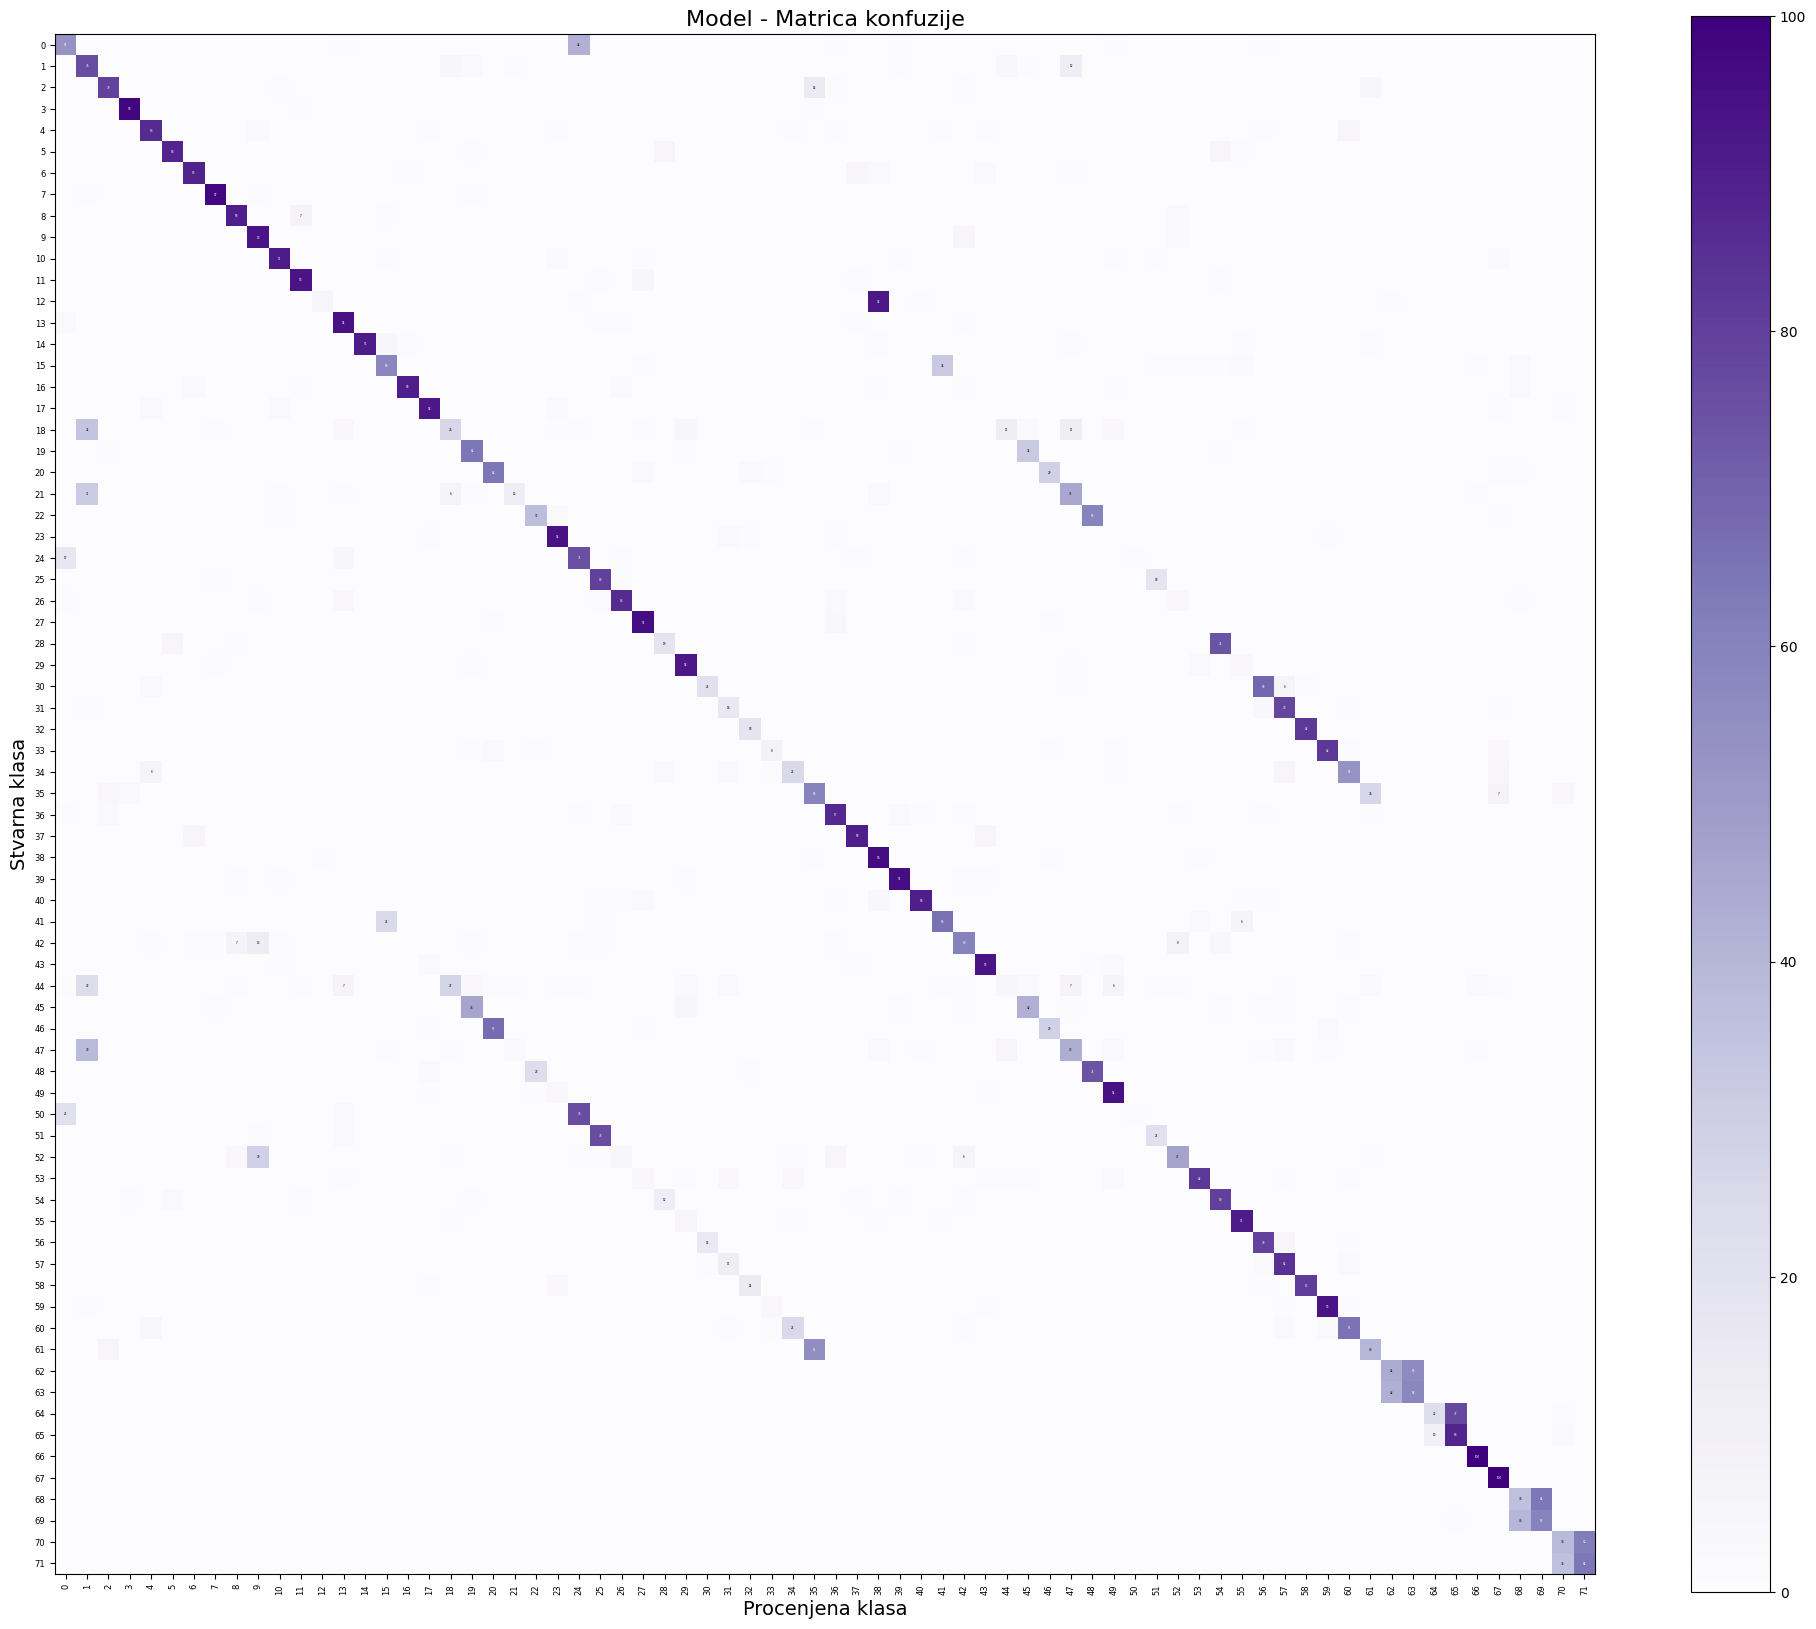

In [93]:
predicted_results_labels_latin = [decimal_to_alphabet(alphabet_latin_labels[result], alphabet_latin, alphabet_latin_labels) for result in predicted_results_latin]
real_labels_latin = [decimal_to_alphabet(x, alphabet_latin, alphabet_latin_labels) for x in real_results_latin]
cm_latin = confusion_matrix_creation(real_labels_latin, predicted_results_labels_latin, 'confusion_matrix_latin.png')

# Testiranje NM nad SVIM testnim slikama

In [16]:
# Funkcija koja se poziva u celiji ispod

def process_image(image_path, ann, alphabet, display_steps=False):     #dodala sam display_steps cisto da mogu da biram jel zelim sve ispisano ili ne
    """
    Procesira sliku: učitavanje, ispravljanje zakošenosti, rotacija, binarizacija i OCR.
    Vraća prepoznat tekst.
    """
    try:
        if display_steps:
            print(f"Učitavam sliku: {image_path}")
        original_image = load_image(image_path)

        if original_image is None:
            raise ValueError("Slika nije uspešno učitana. Proverite putanju i integritet fajla.")

        if display_steps:
            print(f"Slika '{image_path}' uspešno učitana. Dimenzije: {original_image.shape}")
            display_image(original_image, color=True)

            print("\nKorak 1: Ispravljanje zakošenosti")
        skew_corrected_image = correct_skewed_image(original_image.copy())
        if display_steps:
            display_image(skew_corrected_image, color=False)

            print("\nKorak 2: Rotiranje slike")
        rotated_image = rotate_image_to_normal(skew_corrected_image.copy(), image_gray(skew_corrected_image.copy()))
        if display_steps:
            display_image(rotated_image, color=True)

            print("\nKorak 3: Binarizacija slike")
        rotated_image_bin = image_bin(image_gray(rotated_image))
        if display_steps:
            display_image(rotated_image_bin, color=False)

        if display_steps:
            print("\nKorak 4: Prepoznavanje teksta")
        
        recognized_text = extract_text(rotated_image_bin.copy(), ann, alphabet)

        if display_steps:
            print("\nKorak 5: Konačni rezultat:")
            print(recognized_text)

        return recognized_text
        

    except FileNotFoundError:
        print(f"Greška: Slika na putanji '{image_path}' nije pronađena.")
    except NameError as ne:
        print(f"Greška: Nedostaje definicija '{ne}'")
    except ValueError as ve:
        print(f"Greška tokom obrade slike: {ve}")
    
    return None  # Ako nešto krene po zlu

In [17]:
#Pokrecem OCR nad svim ostalim testnim primerima i 
#prikazujem uspesnost upotrebom metrika za stringove

#1. priprema podataka

#1.1kreiram listu test slika i resenja

image_paths_latin = ['../data/test/a01-003x.png/a01-003x.png', '../data/test/a01-007x.png/a01-007x.png', '../data/test/a01-011x.png/a01-011x.png', '../data/test/a01-014x.png/a01-014x.png', '../data/test/a01-020.png/a01-020.png', '../data/test/a01-026.png/a01-026.png', '../data/test/a01-030.png/a01-030.png', '../data/test/a01-030x.png/a01-030x.png', '../data/test/a01-117.png/a01-117.png', '../data/test/a02-000.png/a02-000.png', '../data/test/a02-008.png/a02-008.png', '../data/test/b01-057.png/b01-057.png', '../data/test/b02/b02.png']
image_paths_cyrilic = ['../data/test/c01/c01.png', '../data/test/c02/c02.png', '../data/test/c03/c03.png', '../data/test/c04/c04.png', '../data/test/c05/c05.png','../data/test/c06/c06.png','../data/test/c07/c07.png', '../data/test/c08/c08.png' ]

text_paths_latin = ['../data/test/a01-003x.png/a01-003x.txt', '../data/test/a01-007x.png/a01-007x.txt', '../data/test/a01-011x.png/a01-011x.txt', '../data/test/a01-014x.png/a01-014x.txt', '../data/test/a01-020.png/a01-020.txt', '../data/test/a01-026.png/a01-026.txt', '../data/test/a01-030.png/a01-030.txt', '../data/test/a01-030x.png/a01-030x.txt', '../data/test/a01-117.png/a01-117.txt', '../data/test/a02-000.png/a02-000.txt', '../data/test/a02-008.png/a02-008.txt', '../data/test/b01-057.png/b01-057.txt', '../data/test/b02/b02.txt']
text_paths_cyrilic = ['../data/test/c01/c01.txt', '../data/test/c02/c02.txt', '../data/test/c03/c03.txt', '../data/test/c04/c04.txt', '../data/test/c05/c05.txt', '../data/test/c06/c06.txt', '../data/test/c07/c07.txt','../data/test/c08/c08.txt' ]

image_paths_all = ['../data/test/a01-003x.png/a01-003x.png', '../data/test/a01-007x.png/a01-007x.png', '../data/test/a01-011x.png/a01-011x.png', '../data/test/a01-014x.png/a01-014x.png', '../data/test/a01-020.png/a01-020.png', '../data/test/a01-026.png/a01-026.png', '../data/test/a01-030.png/a01-030.png', '../data/test/a01-030x.png/a01-030x.png', '../data/test/a01-117.png/a01-117.png', '../data/test/a02-000.png/a02-000.png', '../data/test/a02-008.png/a02-008.png', '../data/test/b01-057.png/b01-057.png', '../data/test/b02/b02.png', '../data/test/c01/c01.png', '../data/test/c02/c02.png', '../data/test/c03/c03.png', '../data/test/c04/c04.png', '../data/test/c05/c05.png','../data/test/c06/c06.png','../data/test/c07/c07.png', '../data/test/c08/c08.png' ]
text_paths_all = ['../data/test/a01-003x.png/a01-003x.txt', '../data/test/a01-007x.png/a01-007x.txt', '../data/test/a01-011x.png/a01-011x.txt', '../data/test/a01-014x.png/a01-014x.txt', '../data/test/a01-020.png/a01-020.txt', '../data/test/a01-026.png/a01-026.txt', '../data/test/a01-030.png/a01-030.txt', '../data/test/a01-030x.png/a01-030x.txt', '../data/test/a01-117.png/a01-117.txt', '../data/test/a02-000.png/a02-000.txt', '../data/test/a02-008.png/a02-008.txt', '../data/test/b01-057.png/b01-057.txt', '../data/test/b02/b02.txt', '../data/test/c01/c01.txt', '../data/test/c02/c02.txt', '../data/test/c03/c03.txt', '../data/test/c04/c04.txt', '../data/test/c05/c05.txt', '../data/test/c06/c06.txt', '../data/test/c07/c07.txt','../data/test/c08/c08.txt' ]

test_data = []
test_data_latin = []
test_data_cyrilic = []

#1.2.1 pravim parove (slika, ucitani tekst) za latinicu
for img_path, txt_path in zip(image_paths_latin, text_paths_latin):
    gt_text = Path(txt_path).read_text(encoding='utf-8').strip()
    test_data_latin.append((img_path, gt_text))

#1.2.2 pravim parove (slika, ucitani tekst) za ciliricu
for img_path, txt_path in zip(image_paths_cyrilic, text_paths_cyrilic):
    gt_text = Path(txt_path).read_text(encoding='utf-8').strip()
    test_data_cyrilic.append((img_path, gt_text))

#1.2.3 pravim parove (slika, ucitani tekst) za sve
for img_path, txt_path in zip(image_paths_all, text_paths_all):
    gt_text = Path(txt_path).read_text(encoding='utf-8').strip()
    test_data.append((img_path, gt_text))


In [ ]:
#2. Pokreni adekvatne OCR modele nad svakim 
#2.1 Učitaj sliku.

#Prvo svi
results_all = []

for img_path, gt_text in test_data:
    print(f"Obrada slike: {img_path}")
    prediction = process_image(img_path, model, alphabet, False)
    if prediction is None:
        print("OCR nije uspeo.")
        continue

    results_all.append({
        'ime_slike' : img_path,
        'ground_truth': gt_text,
        'prediction': prediction
    })

#Pa latinica
results_latin = []

for img_path, gt_text in test_data_latin:
    print(f"Obrada slike: {img_path}")
    prediction = process_image(img_path, model_latin, alphabet_latin, False)
    if prediction is None:
        print("OCR nije uspeo.")
        continue

    results_latin.append({
        'ime_slike' : img_path,
        'ground_truth': gt_text,
        'prediction': prediction
    })

#Pa cirilica

results_cyrilic = []

for img_path, gt_text in test_data_cyrilic:
    print(f"Obrada slike: {img_path}")
    prediction = process_image(img_path, model_cyrillic, alphabet, False)
    if prediction is None:
        print("OCR nije uspeo.")
        continue

    results_cyrilic.append({
        'ime_slike' : img_path,
        'ground_truth': gt_text,
        'prediction': prediction
    })



In [20]:
#3. Izračunaj metrike upoređivanjem sa ground truth tekstom
# ideja: za svaki element iz results izracunacu : 
    #Levenstajnovo rastojanje
    #Hamingovo rastojanje
    #Accuracy

print("Ispis metrika za generalni model:")

for r in results_all:
    gt = r['ground_truth']
    pred = r['prediction']

    #ovo dodajem da se osiguram da su i gt i pred stringovi
    #jer je pre javljalo gresku
    gt = ''.join(r['ground_truth']) if isinstance(r['ground_truth'], list) else str(r['ground_truth'])
    pred = ''.join(r['prediction']) if isinstance(r['prediction'], list) else str(r['prediction'])

    r['levenshtein'] = Levenshtein.distance(pred, gt)

    if len(gt) == len(pred):
        r['hamming'] = sum(c1 != c2 for c1, c2 in zip(gt, pred))
    else:
        r['hamming'] = None

    # 3.1 Accuracy = broj tačnih karaktera / ukupno karaktera
    tacni = sum(c1 == c2 for c1, c2 in zip(gt, pred))
    r['accuracy'] = tacni / max(len(gt), len(pred), 1)  # štiti od deljenja sa nulom

for r in results_all:
    print("Preciznost: ", r["accuracy"])
    print("Levenštajnovo rastojanje: ", r["levenshtein"])
    print("Hamingovo rastojanje: ", r["hamming"])
    print()

print("Ispis metrika za cirilicni model:")

for r in results_cyrilic:
    gt = r['ground_truth']
    pred = r['prediction']

    #ovo dodajem da se osiguram da su i gt i pred stringovi
    #jer je pre javljalo gresku
    gt = ''.join(r['ground_truth']) if isinstance(r['ground_truth'], list) else str(r['ground_truth'])
    pred = ''.join(r['prediction']) if isinstance(r['prediction'], list) else str(r['prediction'])

    r['levenshtein'] = Levenshtein.distance(pred, gt)

    if len(gt) == len(pred):
        r['hamming'] = sum(c1 != c2 for c1, c2 in zip(gt, pred))
    else:
        r['hamming'] = None

    # 3.1 Accuracy = broj tačnih karaktera / ukupno karaktera
    tacni = sum(c1 == c2 for c1, c2 in zip(gt, pred))
    r['accuracy'] = tacni / max(len(gt), len(pred), 1)  # štiti od deljenja sa nulom

for r in results_cyrilic:
    print("Preciznost: ", r["accuracy"])
    print("Levenštajnovo rastojanje: ", r["levenshtein"])
    print("Hamingovo rastojanje: ", r["hamming"])
    print()

print("Ispis metrika za latinicni model:")

for r in results_latin:
    gt = r['ground_truth']
    pred = r['prediction']

    #ovo dodajem da se osiguram da su i gt i pred stringovi
    #jer je pre javljalo gresku
    gt = ''.join(r['ground_truth']) if isinstance(r['ground_truth'], list) else str(r['ground_truth'])
    pred = ''.join(r['prediction']) if isinstance(r['prediction'], list) else str(r['prediction'])

    r['levenshtein'] = Levenshtein.distance(pred, gt)

    if len(gt) == len(pred):
        r['hamming'] = sum(c1 != c2 for c1, c2 in zip(gt, pred))
    else:
        r['hamming'] = None

    # 3.1 Accuracy = broj tačnih karaktera / ukupno karaktera
    tacni = sum(c1 == c2 for c1, c2 in zip(gt, pred))
    r['accuracy'] = tacni / max(len(gt), len(pred), 1)  # štiti od deljenja sa nulom

for r in results_latin:
    print("Preciznost: ", r["accuracy"])
    print("Levenštajnovo rastojanje: ", r["levenshtein"])
    print("Hamingovo rastojanje: ", r["hamming"])
    print()

Ispis metrika za generalni model:
Preciznost:  0.02466367713004484
Levenštajnovo rastojanje:  369
Hamingovo rastojanje:  None

Preciznost:  0.0215633423180593
Levenštajnovo rastojanje:  310
Hamingovo rastojanje:  None

Preciznost:  0.03367875647668394
Levenštajnovo rastojanje:  324
Hamingovo rastojanje:  None

Preciznost:  0.017721518987341773
Levenštajnovo rastojanje:  338
Hamingovo rastojanje:  None

Preciznost:  0.04043126684636118
Levenštajnovo rastojanje:  291
Hamingovo rastojanje:  None

Preciznost:  0.029082774049217
Levenštajnovo rastojanje:  340
Hamingovo rastojanje:  None

Preciznost:  0.02666666666666667
Levenštajnovo rastojanje:  404
Hamingovo rastojanje:  None

Preciznost:  0.02
Levenštajnovo rastojanje:  326
Hamingovo rastojanje:  None

Preciznost:  0.021505376344086023
Levenštajnovo rastojanje:  381
Hamingovo rastojanje:  None

Preciznost:  0.026470588235294117
Levenštajnovo rastojanje:  270
Hamingovo rastojanje:  None

Preciznost:  0.032679738562091505
Levenštajnovo ras